# Inference and Evaluation of Pretrained E. coli FluxTransformers

Explore and visualize the behavior of a pretrained FluxTransformer model on E. coli iML1515 metabolism. Includes loss curves, diagnostic plots for chosen fluxes, PCA and t-SNE plots, and flux metrics.

This model is meant to be used with experimental data.

In [23]:
import os
from dotenv import load_dotenv

load_dotenv()
hf_token = os.getenv("HFTOKEN")

In [2]:
from datetime import date

import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from IPython.display import display, Image

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.animation import FuncAnimation, PillowWriter
from openTSNE import TSNEEmbedding, affinity, initialization

from train_flux_transformer import load_data, prepare_tensors, set_seed

%matplotlib inline
pd.set_option('display.max_rows', None)

In [2]:
class AttentionBlock(nn.Module):
    """Custom multi-head attention block for metabolic modeling"""
    def __init__(self, d_model=128, n_heads=8, dropout=0.05):
        super().__init__()
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"

        self.d_model = d_model
        self.n_heads = n_heads
        self.layer_norm = nn.LayerNorm(d_model)

        self.mha = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        self.head_scores = nn.Parameter(torch.zeros(n_heads))

    def forward(self, x, c):
        # x: (batch, seq_len, d_model)
        # c: (batch, seq_len, 1)
        x_norm = self.layer_norm(x) # pre-norm
        attn_out, attn_weights = self.mha(x_norm, x_norm, x_norm, need_weights=True, average_attn_weights=False)

        x_out = attn_out + x

        # Per-head diffusion of c:
        c_heads = torch.matmul(attn_weights, c.unsqueeze(1))
        alpha = F.softmax(self.head_scores, dim=0).view(1, self.n_heads, 1, 1)  # (1,H,1,1)
        c_att = (c_heads * alpha).sum(dim=1)  # (B, S, 1)

        c_out = c_att + c

        return x_out, c_out

In [3]:
class FeedForwardBlock(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.05):
        super().__init__()

        self.d_model = d_model + 1
        self.d_ff = d_ff

        self.layer_norm = nn.LayerNorm(self.d_model)
        self.linear1 = nn.Linear(self.d_model, self.d_ff)
        self.activation = nn.GELU()
        self.linear2 = nn.Linear(self.d_ff, self.d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, c):
        y = torch.cat((x, c), dim=2)
        
        norm_y = self.layer_norm(y)
        hidden = self.linear1(norm_y)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        output = self.linear2(hidden)

        return output + y

In [4]:
class FluxTransformerLayer(nn.Module):
    """Single transformer block without embedding layer"""
    def __init__(self, d_model=128, n_heads=8, d_ff=1024, dropout=0.05):
        super().__init__()
        self.d_model = d_model
        
        self.attention_block = AttentionBlock(d_model, n_heads, dropout)
        self.feedforward_block = FeedForwardBlock(d_model, d_ff, dropout)
        
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
    
    def forward(self, x, c):
        attn_x, attn_c = self.attention_block(x, c)
        ff_output = self.feedforward_block(attn_x, attn_c)
        
        # Split the concatenated output
        updated_x = ff_output[:, :, :-1]
        updated_c = ff_output[:, :, -1:]
        
        return updated_x, updated_c
        
class FluxTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        input_token_indices,          # list[int] or 1D tensor[int64]
        d_model=128,
        n_heads=8,
        n_layers=3,
        d_ff=1024,
        dropout=0.05,
    ):
        super().__init__()
        if vocab_size is None:
            raise ValueError("vocab_size must be provided explicitly.")
        self.vocab_size = int(vocab_size)
        self.d_model = d_model

        idx = torch.as_tensor(input_token_indices, dtype=torch.long)
        if idx.ndim != 1:
            raise ValueError("input_token_indices must be 1D.")
        if (idx < 0).any() or (idx >= self.vocab_size).any():
            raise ValueError("input_token_indices contains out-of-range indices.")
        # Register as buffer so it moves with .to(device)
        self.register_buffer("input_token_indices", idx, persistent=True)

        self.input_embedding = nn.Embedding(self.vocab_size, d_model)

        self.layers = nn.ModuleList([
            FluxTransformerLayer(d_model=d_model, n_heads=n_heads, d_ff=d_ff, dropout=dropout)
            for _ in range(n_layers)
        ])

    def forward(self, c, output_subset=None, return_embedding=False):
        """
        c: (batch, vocab_size, 1)
        output_subset: 1D tensor of token indices to train on (typically excludes injected tokens)
        """
        batch_size = c.size(0)

        always = self.input_token_indices  # (n_injected,)

        if output_subset is None:
            selected_indices = torch.arange(self.vocab_size, device=c.device)
        else:
            output_subset = output_subset.to(c.device).long()
            selected_indices = torch.unique(torch.cat([always, output_subset]), sorted=True)

        y = selected_indices.unsqueeze(0).expand(batch_size, -1)      # (B, S)
        x = self.input_embedding(y)                                    # (B, S, d_model)

        c_subset = c[:, selected_indices, :]                           # (B, S, 1)
        c_subset_all_layers = torch.zeros(batch_size, c_subset.size(1), len(self.layers), device=c.device)

        for e, layer in enumerate(self.layers):
            x, c_subset = layer(x, c_subset)
            c_subset_all_layers[:, :, e] = c_subset.squeeze(-1)

        if return_embedding:
            return x, selected_indices

        return c_subset_all_layers, selected_indices

In [5]:
def load_pretrained_model(checkpoint_path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    Load a pretrained model from a checkpoint file
    
    Args:
        checkpoint_path: Path to the checkpoint file (*_checkpoint.pth)
        device: Device to load the model onto
        
    Returns:
        model: Loaded FluxTransformer model
        config: Model configuration dictionary
        data_info: Data information dictionary
    """
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    
    # Extract configuration
    config = checkpoint['config']
    train_losses = checkpoint['train_losses']
    test_losses = checkpoint['test_losses']

    # Initialize model with saved configuration
    model = FluxTransformer(
        vocab_size=config['vocab_size'],
        input_token_indices=config['input_token_indices'],
        d_model=config['d_model'],
        n_heads=config['n_heads'],
        n_layers=config['n_layers'],
        d_ff=config['d_ff'],
        dropout=config['dropout']
    ).to(device)
    
    # Load model weights
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()  # Set to evaluation mode
    
    print(f"Loaded model from {checkpoint_path}")
    print(f"Configuration: d_model={config['d_model']}, "
          f"n_heads={config['n_heads']}, n_layers={config['n_layers']}, d_ff={config['d_ff']}")
    
    return model, config, train_losses, test_losses, checkpoint['data_info']

### Plotting Functions

In [6]:
def plot_loss_curves(train_losses, test_losses, d_model, n_heads, n_layers, d_ff, save_path=None, log_scale=True):
    plt.figure(figsize=(14, 10))
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.plot(train_losses, label="Training Loss")
    plt.plot(test_losses, label="Test Loss")
    if log_scale:
        plt.yscale('log')
    plt.xlabel("Epoch", fontsize=18)
    plt.ylabel("Loss", fontsize=18)
    plt.title(f"Loss Curves (d={d_model}, h={n_heads}, l={n_layers}, ff={d_ff})", fontsize=20)
    plt.grid(True)
    plt.legend(fontsize=16)
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        plt.close()
        print(f"\nTraining curve saved to {save_path}")
    else:
        plt.show()

In [7]:
def plot_diagnostics_2x2(y_true, y_pred, label, save_path=None):
    """Creates a 2x2 matrix of plots: true vs predicted, residuals, error distribution, and histogram of samples."""
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    residuals = y_true - y_pred

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # True vs Predicted
    axs[0, 0].scatter(y_true, y_pred, alpha=0.2, s=5, color='royalblue')
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    axs[0, 0].plot([lo, hi], [lo, hi], 'k--', lw=2)
    axs[0, 0].set_title(f'True vs Predicted: {label}')
    axs[0, 0].set_xlabel('True value')
    axs[0, 0].set_ylabel('Predicted')
    axs[0, 0].grid(True)

    # Residuals plot
    axs[0, 1].scatter(y_true, residuals, alpha=0.15, color='darkorange')
    axs[0, 1].axhline(y=0, color='r', linestyle='-')
    axs[0, 1].set_title(f'Residuals: {label}')
    axs[0, 1].set_xlabel('True value')
    axs[0, 1].set_ylabel('Residuals')
    axs[0, 1].grid(True)

    # Error distribution
    sns.histplot(residuals, kde=True, ax=axs[1, 0], legend=False, color='indianred')
    axs[1, 0].set_title(f'Prediction Error Distribution: {label}')
    axs[1, 0].set_xlabel('Prediction Error')
    axs[1, 0].set_ylabel('Frequency')
    axs[1, 0].grid(True)

    # Histogram of actual values
    sns.histplot(y_true, kde=True, bins=100, ax=axs[1, 1], legend=False, color='mediumseagreen')
    axs[1, 1].set_title(f'True Value Distribution: {label}')
    axs[1, 1].set_xlabel('True Value')
    axs[1, 1].set_ylabel('Frequency')
    axs[1, 1].grid(True)

    plt.tight_layout()
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches='tight', dpi=300)
        plt.close(fig)
    else:
        plt.show()
        plt.close(fig)

In [8]:
def plot_flux(
    model,
    X_test,
    y_test,
    outputs,
    flux_name: str,
    save_path=None,
    batch_size: int = 16,
    device: str | torch.device | None = None,
):
    """
    Plot diagnostics for a token name in `outputs`.

    Assumptions:
      - outputs defines token order, len(outputs) == model.vocab_size
      - X_test is (N, vocab_size) and contains medium constraints only at injected token indices
      - y_test is (N, vocab_size) and contains realized fluxes for all tokens
      - model forward returns (preds_all_layers, selected_indices)
        where preds_all_layers is (B, S, n_layers) and selected_indices are token indices
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    device = torch.device(device)

    model = model.to(device).eval()

    # Basic sanity checks
    if len(outputs) != getattr(model, "vocab_size", None):
        raise ValueError(f"len(outputs)={len(outputs)} does not match model.vocab_size={model.vocab_size}")

    if X_test.ndim != 2 or y_test.ndim != 2:
        raise ValueError(f"Expected X_test and y_test as 2D tensors (N, vocab_size). Got {X_test.shape=}, {y_test.shape=}")

    if X_test.shape[1] != model.vocab_size or y_test.shape[1] != model.vocab_size:
        raise ValueError(
            f"Feature dim mismatch. Expected vocab_size={model.vocab_size}. "
            f"Got X_test.shape[1]={X_test.shape[1]}, y_test.shape[1]={y_test.shape[1]}"
        )

    if flux_name not in outputs:
        raise ValueError(f"Flux '{flux_name}' not in outputs (len={len(outputs)}).")

    token_idx = outputs.index(flux_name)

    pred_vals = []
    true_vals = []
    pos = None

    with torch.no_grad():
        for i in range(0, X_test.shape[0], batch_size):
            xb = X_test[i:i + batch_size].to(device)          # [B, vocab_size]
            yb_true = y_test[i:i + batch_size]                # [B, vocab_size]
            c = xb.unsqueeze(-1)                              # [B, vocab_size, 1]

            preds_all_layers, selected_indices = model(c, output_subset=None)

            # Map token_idx -> its position inside selected_indices (once is enough)
            if pos is None:
                selected_indices_np = selected_indices.detach().cpu().numpy()
                if selected_indices_np.ndim > 1:
                    selected_indices_np = selected_indices_np[0]
                hit = np.where(selected_indices_np == token_idx)[0]
                if hit.size == 0:
                    raise RuntimeError(
                        f"Token index {token_idx} for '{flux_name}' was not produced by the model forward pass. "
                        "This should not happen when output_subset=None."
                    )
                pos = int(hit[0])

            yb_pred_flux = preds_all_layers[:, pos, -1].detach().cpu().numpy()
            yb_true_flux = yb_true[:, token_idx].detach().cpu().numpy()

            pred_vals.append(yb_pred_flux)
            true_vals.append(yb_true_flux)

            if device.type == "cuda":
                torch.cuda.empty_cache()

    y_pred = np.concatenate(pred_vals, axis=0)
    y_true = np.concatenate(true_vals, axis=0)

    # Is this an injected (medium constraint) token slot?
    injected = False
    if hasattr(model, "input_token_indices") and model.input_token_indices is not None:
        injected = bool((model.input_token_indices.detach().cpu() == token_idx).any().item())

    print(f"{flux_name} token index: {token_idx}")
    print(f"injected medium slot: {injected}")
    print("y_true range:", float(y_true.min()), "to", float(y_true.max()))
    print("y_pred range:", float(y_pred.min()), "to", float(y_pred.max()))

    plot_diagnostics_2x2(
        y_true=y_true,
        y_pred=y_pred,
        label=flux_name,
        save_path=save_path
    )

### Load model

In [9]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [10]:
model_name = "iML1515_500k_d256_h8_l3_ff1024"
checkpoint_path = f"./models/{model_name}/{model_name}_checkpoint.pth"

 # Load the model
model, config, train_losses, test_losses, data_info = load_pretrained_model(checkpoint_path, device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal number of parameters: {total_params:,}")

# Print data information
print("\nData information:")
print(f"Dataset: {data_info['dataset']}")
print(f"Training samples: {data_info['n_train']}")
print(f"Test samples: {data_info['n_test']}")

Loaded model from ./models/iML1515_500k_d256_h8_l3_ff1024/iML1515_500k_d256_h8_l3_ff1024_checkpoint.pth
Configuration: d_model=256, n_heads=8, n_layers=3, d_ff=1024

Total number of parameters: 3,069,729

Data information:
Dataset: ./data/iML1515_exp_training_data_500000_samples.csv
Training samples: 400000
Test samples: 100000


### Load data

In [11]:
# Load data using the same function as during training
set_seed()

DATA_PATH = f"./data/iML1515_test_data_50000_samples.csv"

#X, y, inputs, outputs, input_token_indices, out_indices = load_data(data_info['dataset'])
X, y, inputs, outputs, input_token_indices, out_indices = load_data(DATA_PATH)

X_train, X_test, y_train, y_test = prepare_tensors(X, y, device=device)

model.eval()


Loaded data with 50000 samples from ./data/iML1515_test_data_50000_samples.csv
Extracted input columns count:  38
Extracted output columns count: 2712
Medium constraints are injected into these token indices (in outputs order):
[114, 1439, 288, 303, 206, 209, 106, 347, 112, 111, 99, 40, 45, 92, 104, 164, 304, 621, 700, 859, 913, 970, 1424, 1478, 1485, 1500, 1534, 1535, 1836, 1981, 86, 934, 2243, 2320, 108, 98, 1490, 217]
Training samples: 40000
Test samples: 10000


FluxTransformer(
  (input_embedding): Embedding(2712, 256)
  (layers): ModuleList(
    (0-2): 3 x FluxTransformerLayer(
      (attention_block): AttentionBlock(
        (layer_norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (mha): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
        )
      )
      (feedforward_block): FeedForwardBlock(
        (layer_norm): LayerNorm((257,), eps=1e-05, elementwise_affine=True)
        (linear1): Linear(in_features=257, out_features=1024, bias=True)
        (activation): GELU(approximate='none')
        (linear2): Linear(in_features=1024, out_features=257, bias=True)
        (dropout): Dropout(p=0.02, inplace=False)
      )
    )
  )
)

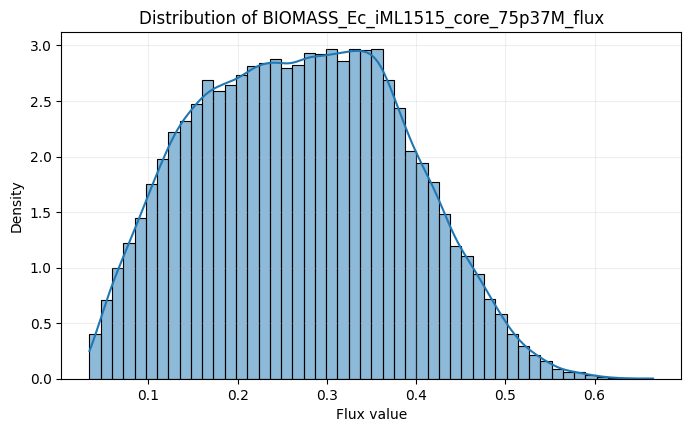

In [12]:
def plot_flux_distribution(y, outputs, flux_name, bins=50, figsize=(8, 4.5)):
    """Plot the distribution of a selected output flux from target tensor y."""
    if flux_name not in outputs:
        raise ValueError(f"{flux_name} not found in outputs.")
    flux_idx = outputs.index(flux_name)
    flux_values = y[:, flux_idx]
    if isinstance(flux_values, torch.Tensor):
        flux_values = flux_values.detach().cpu().numpy()
    else:
        flux_values = np.asarray(flux_values)

    plt.figure(figsize=figsize)
    sns.histplot(flux_values, bins=bins, kde=True, stat="density", color="tab:blue")
    plt.title(f"Distribution of {flux_name}")
    plt.xlabel("Flux value")
    plt.ylabel("Density")
    plt.grid(alpha=0.2)
    plt.show()

plot_flux_distribution(y, outputs, "BIOMASS_Ec_iML1515_core_75p37M_flux")

### Plot Results

In [13]:
today = date.today().isoformat()
pic_dir = f"./pics/{today}/{model_name}"

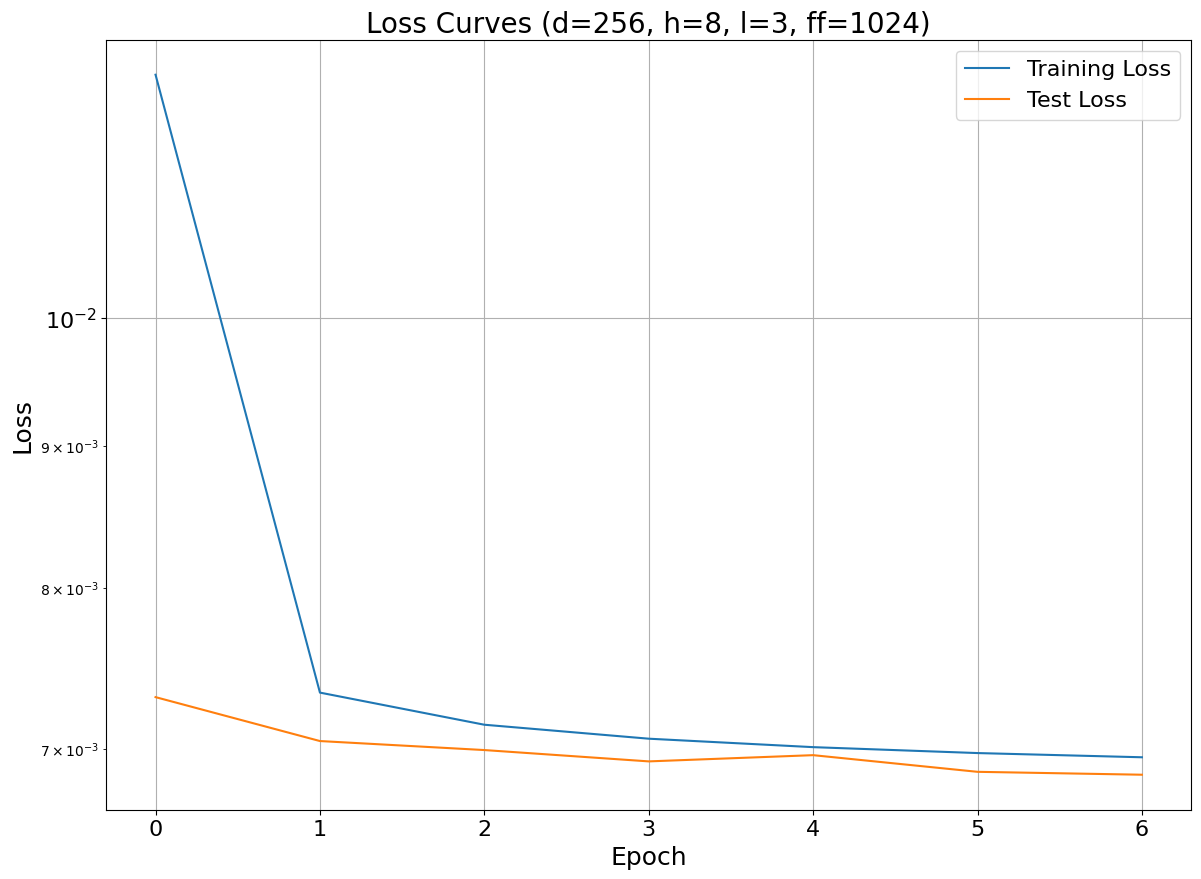

In [14]:
plot_loss_curves(
    train_losses,
    test_losses,
    d_model=config['d_model'],
    n_heads=config['n_heads'],
    n_layers=config['n_layers'],
    d_ff=config['d_ff']
)

BIOMASS_Ec_iML1515_core_75p37M_flux:
------------------------------------------------------------
BIOMASS_Ec_iML1515_core_75p37M_flux token index: 2668
injected medium slot: False
y_true range: 0.034536972641944885 to 0.6040152311325073
y_pred range: 0.04416623339056969 to 0.6153146028518677


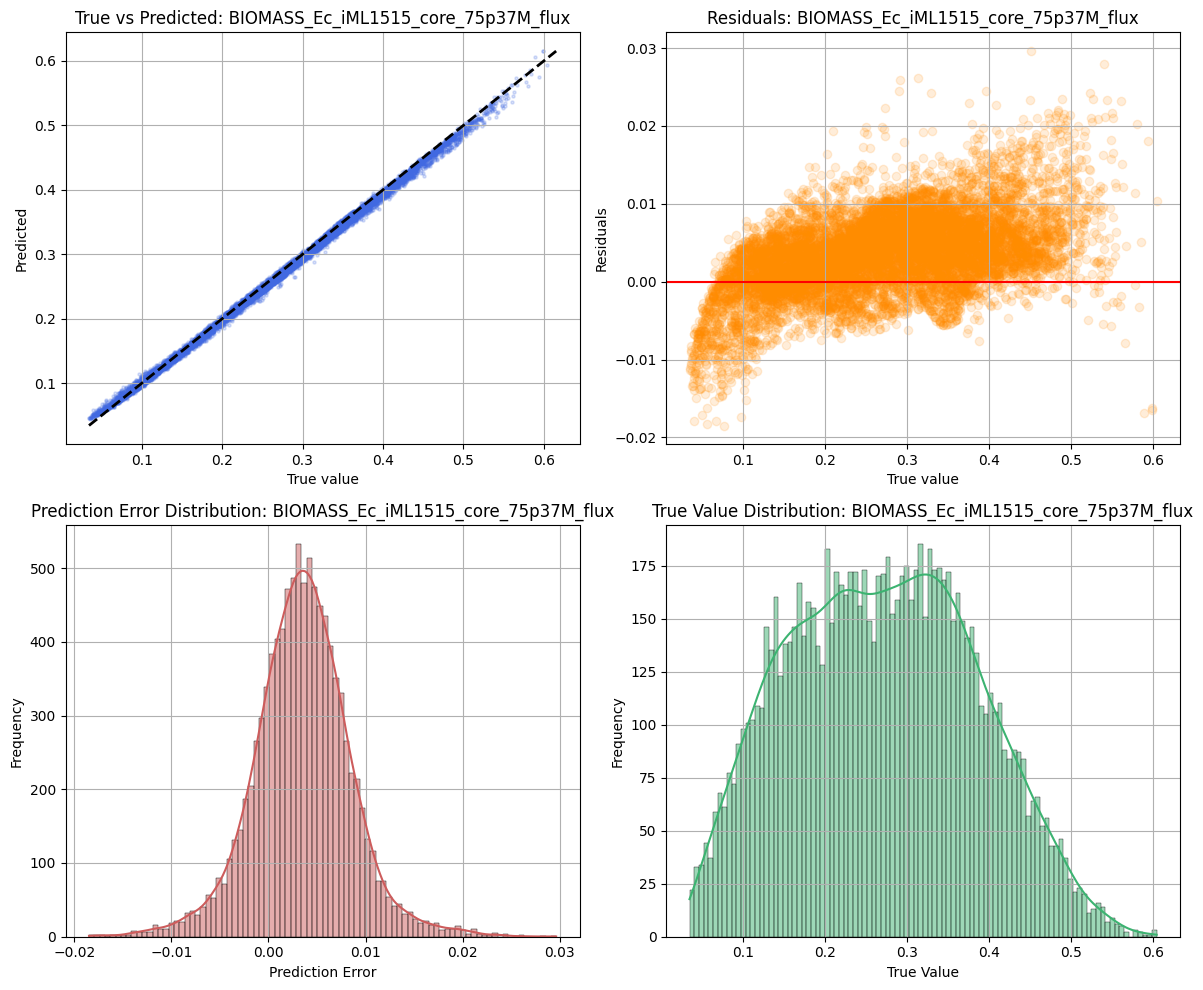

In [15]:
diagnostics_to_plot = ['BIOMASS_Ec_iML1515_core_75p37M_flux']

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

ATPS4rpp_flux:
------------------------------------------------------------
ATPS4rpp_flux token index: 798
injected medium slot: False
y_true range: -3.992703437805176 to 33.71150207519531
y_pred range: -2.956604480743408 to 33.28322982788086


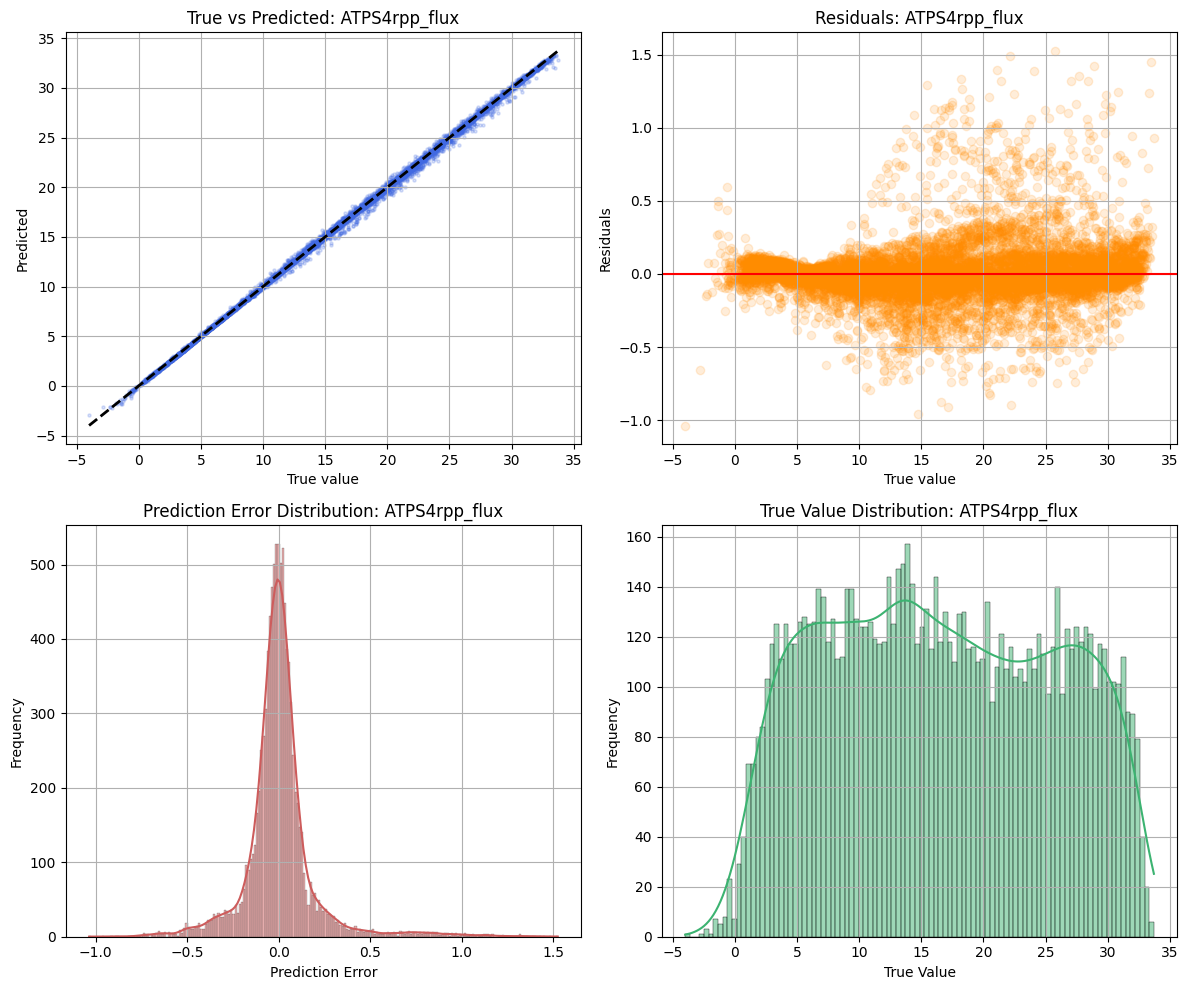

CYTBO3_4pp_flux:
------------------------------------------------------------
CYTBO3_4pp_flux token index: 1871
injected medium slot: False
y_true range: 1.999932050704956 to 19.999826431274414
y_pred range: 2.0541892051696777 to 19.935354232788086


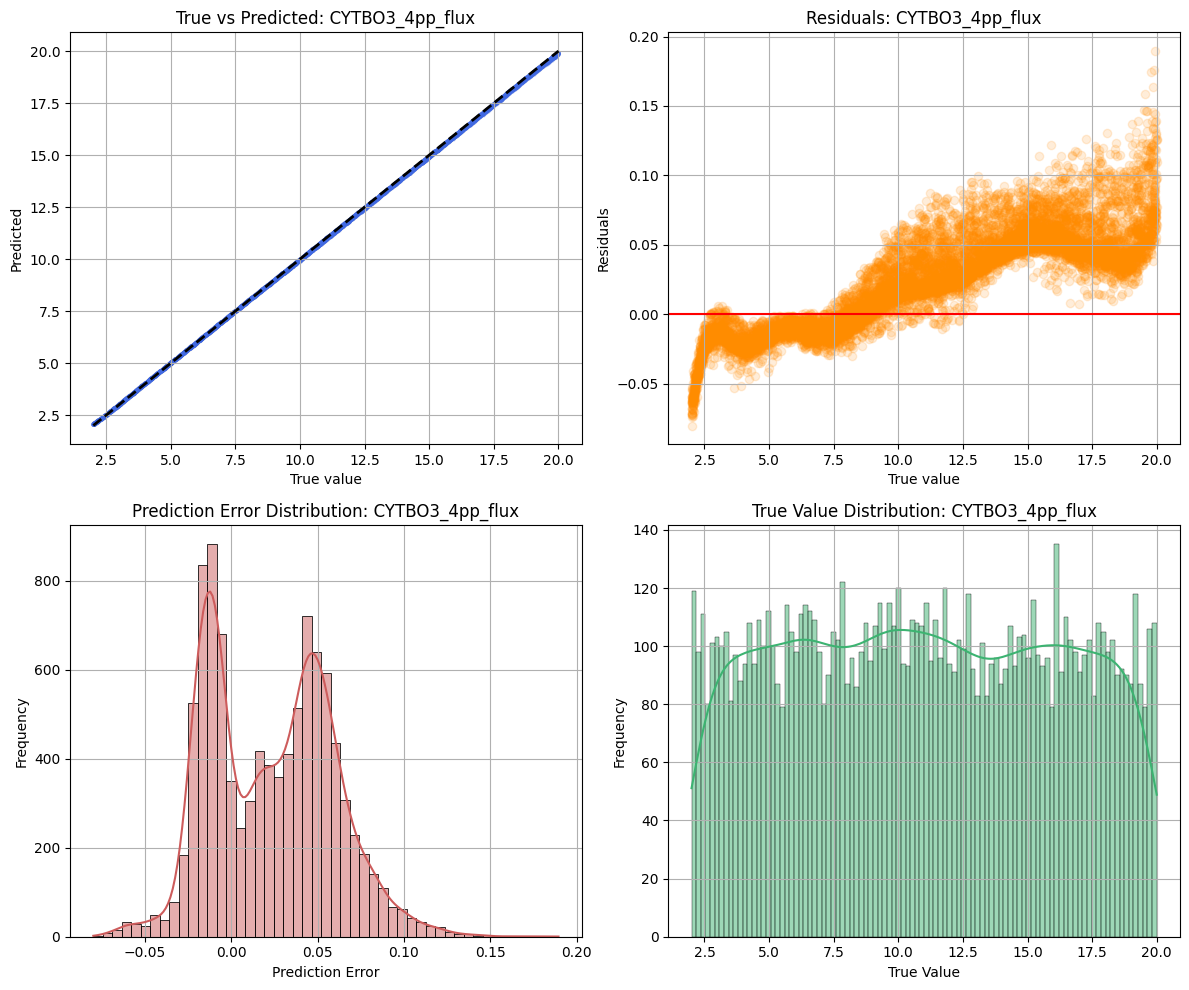

NADH16pp_flux:
------------------------------------------------------------
NADH16pp_flux token index: 2230
injected medium slot: False
y_true range: 0.0 to 19.07014274597168
y_pred range: 1.495328426361084 to 18.8043270111084


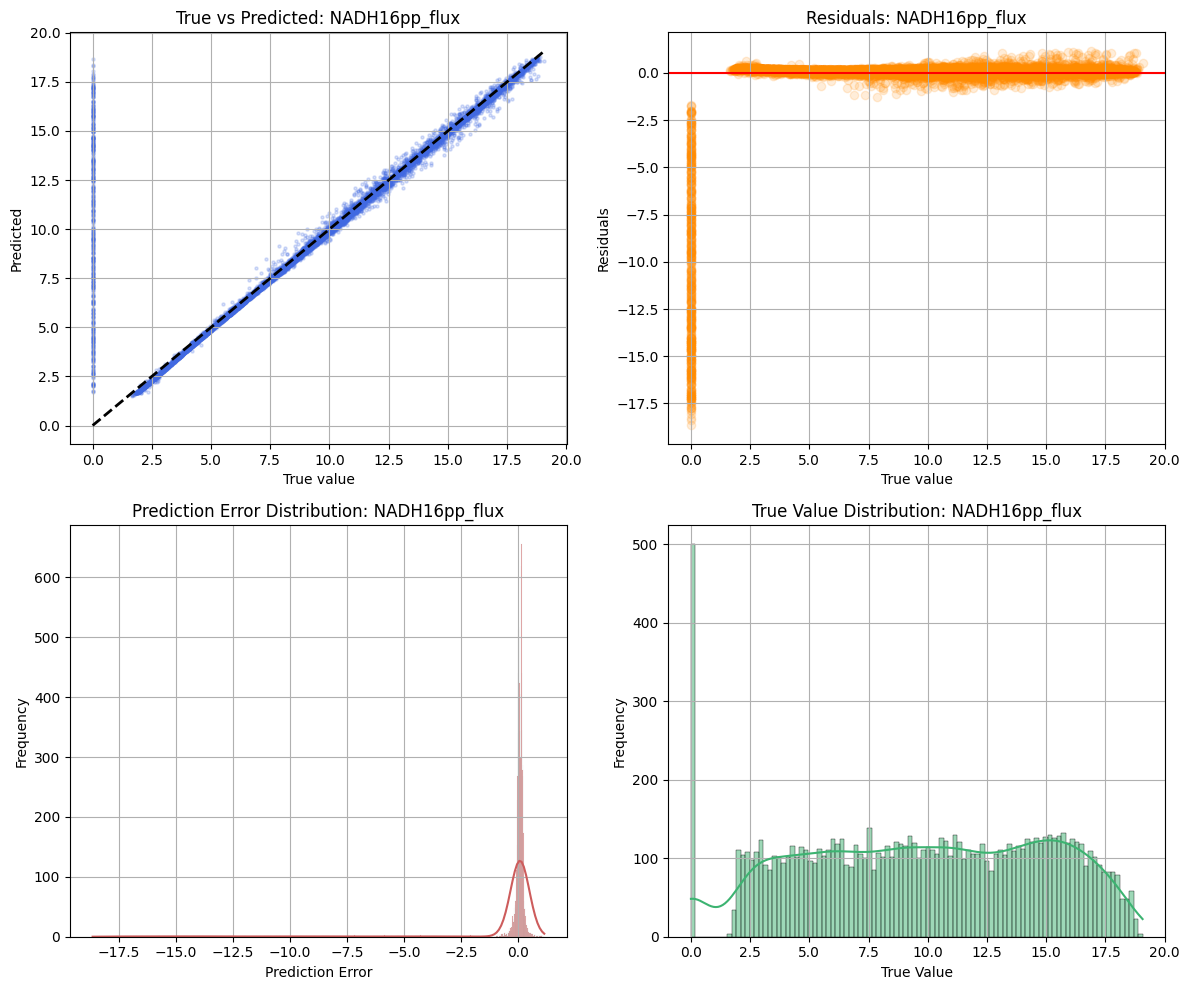

GAPD_flux:
------------------------------------------------------------
GAPD_flux token index: 601
injected medium slot: False
y_true range: 1.2836081981658936 to 24.647706985473633
y_pred range: 1.3528122901916504 to 23.97534942626953


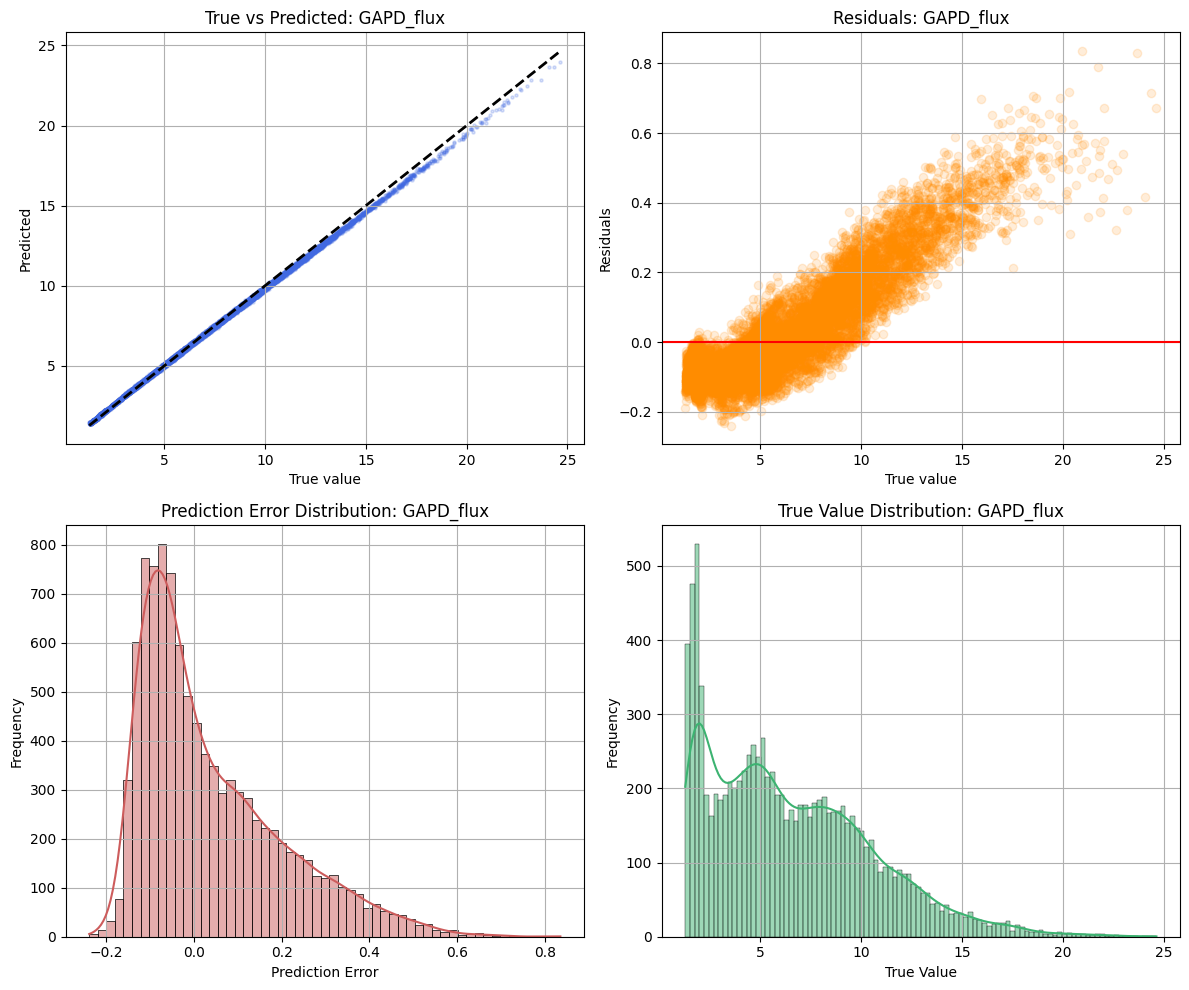

ENO_flux:
------------------------------------------------------------
ENO_flux token index: 126
injected medium slot: False
y_true range: 1.2836081981658936 to 24.647706985473633
y_pred range: 1.3250941038131714 to 23.845199584960938


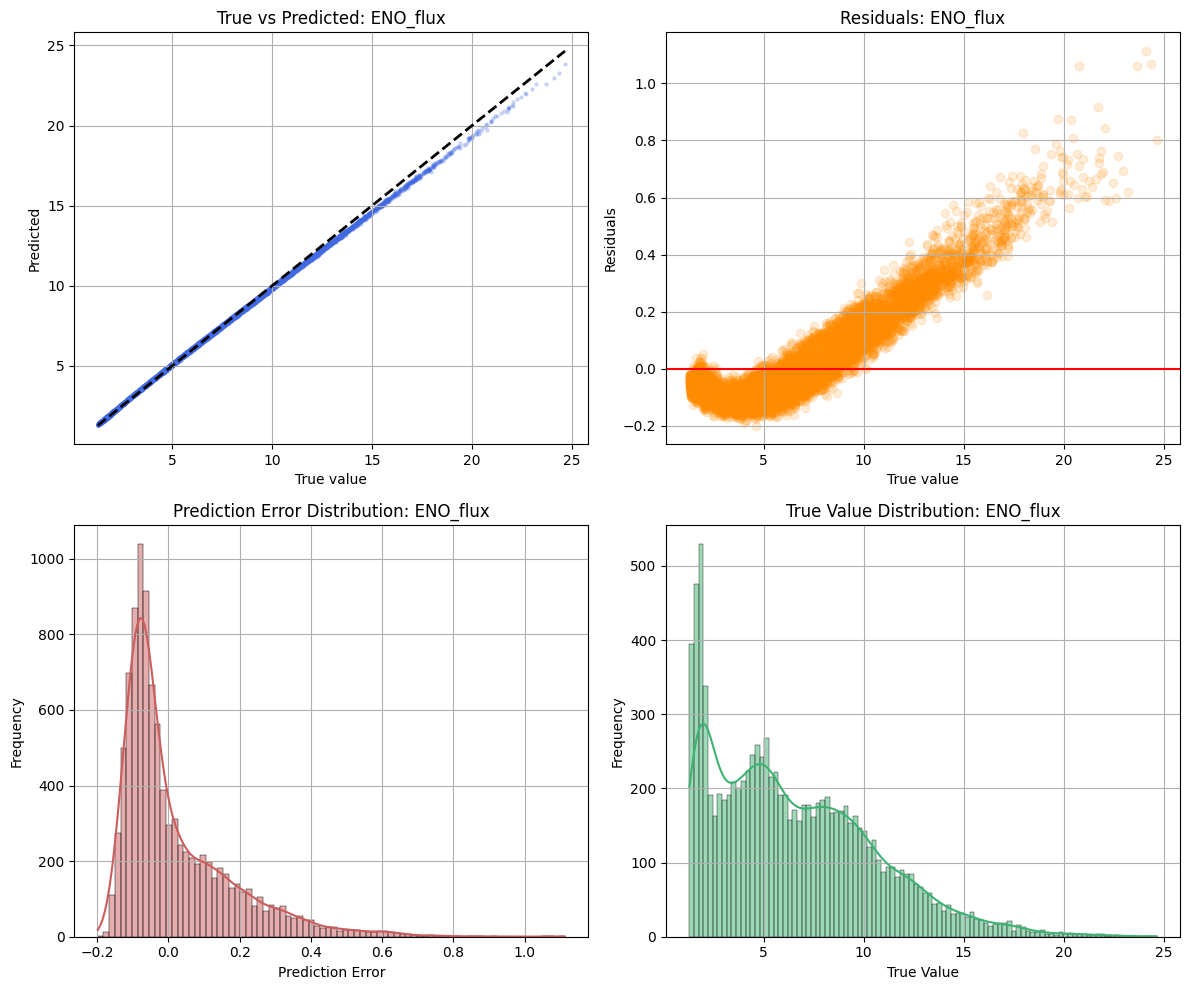

In [16]:
diagnostics_to_plot = ['ATPS4rpp_flux', 'CYTBO3_4pp_flux', 'NADH16pp_flux', 'GAPD_flux', 'ENO_flux', ]

for flux_name in diagnostics_to_plot:
    save_path = f"{pic_dir}/{flux_name}"
    print(f'{flux_name}:')
    print(60 * '-')
    plot_flux(model, X_test, y_test, outputs, flux_name, save_path=None)

### Reservoir Computing on Experimental Data (Frozen FluxTransformer + Prior Dense Net)


In [17]:
from torch.utils.data import TensorDataset, DataLoader

EXP_PATH = "./experimental_data/iML1515_EXP.csv"
GROWTH_TARGET_COL = "GR_AVG"
BIOMASS_TOKEN = "BIOMASS_Ec_iML1515_core_75p37M_flux"

exp_df = pd.read_csv(EXP_PATH).fillna(0.0)

# Normalize experimental column names to match model input names.
# Example: EX_pi_e_i -> EX_pi_e
normalized_cols = {c: c[:-2] if c.endswith("_i") else c for c in exp_df.columns}
exp_df = exp_df.rename(columns=normalized_cols)

missing_inputs = [c for c in inputs if c not in exp_df.columns]
if missing_inputs:
    raise ValueError(f"Missing expected input columns in experimental data: {missing_inputs}")
if GROWTH_TARGET_COL not in exp_df.columns:
    raise ValueError(f"Missing growth target column: {GROWTH_TARGET_COL}")
if BIOMASS_TOKEN not in outputs:
    raise ValueError(f"Biomass token not found in outputs: {BIOMASS_TOKEN}")

# Only variable media are learned by the front ANN, fixed media stay constant.
TRAINABLE_EXTRA_INPUTS = {"EX_o2_e"}  # force oxygen to be trainable with variable carbons
variable_input_cols = [c for c in inputs if (exp_df[c].nunique(dropna=False) > 1) or (c in TRAINABLE_EXTRA_INPUTS)]
fixed_input_cols = [c for c in inputs if c not in variable_input_cols]

if len(variable_input_cols) == 0:
    raise ValueError("No variable input columns found in experimental dataset.")

biomass_idx = outputs.index(BIOMASS_TOKEN)

print(f"Experimental samples: {len(exp_df)}")
print(f"Total media inputs: {len(inputs)}")
print(f"Variable media inputs learned by prior ANN: {len(variable_input_cols)}")
print(f"Fixed media inputs kept constant: {len(fixed_input_cols)}")
print(f"Biomass output token index: {biomass_idx}")

var_pos = torch.tensor([inputs.index(c) for c in variable_input_cols], dtype=torch.long, device=device)
fixed_pos = torch.tensor([inputs.index(c) for c in fixed_input_cols], dtype=torch.long, device=device)
token_idx = torch.tensor(input_token_indices, dtype=torch.long, device=device)

X_var = torch.tensor(exp_df[variable_input_cols].to_numpy(dtype=np.float32), dtype=torch.float32, device=device)
y_growth = torch.tensor(exp_df[GROWTH_TARGET_COL].to_numpy(dtype=np.float32), dtype=torch.float32, device=device)

# Convert fixed presence flags (0/1) into physical bounds, aligned with simulation generator.
BASE_DEFAULT_RATE = 10.0
AMINO_RATE = 2.2
FIXED_SPECIAL_RATES = {
    "EX_glyc_e": AMINO_RATE,
}
AMINO_EXCHANGES = {"EX_ala__L_e", "EX_pro__L_e", "EX_thr__L_e", "EX_gly_e"}

def fixed_presence_to_bound(col_name, presence_value):
    if presence_value <= 0:
        return 0.0
    if col_name in FIXED_SPECIAL_RATES:
        return FIXED_SPECIAL_RATES[col_name]
    if col_name in AMINO_EXCHANGES:
        return AMINO_RATE
    return BASE_DEFAULT_RATE

if len(fixed_input_cols) > 0:
    fixed_presence = exp_df[fixed_input_cols].iloc[0].to_numpy(dtype=np.float32)
    fixed_bound_values = np.array(
        [fixed_presence_to_bound(c, v) for c, v in zip(fixed_input_cols, fixed_presence)],
        dtype=np.float32,
    )
    fixed_values = torch.tensor(fixed_bound_values, dtype=torch.float32, device=device)
else:
    fixed_values = torch.empty(0, dtype=torch.float32, device=device)

print("Variable input columns:")
print(variable_input_cols)
print("Fixed input bounds used (derived from presence flags):")
print({c: float(v) for c, v in zip(fixed_input_cols, fixed_values.detach().cpu().numpy())})

Experimental samples: 110
Total media inputs: 38
Variable media inputs learned by prior ANN: 11
Fixed media inputs kept constant: 27
Biomass output token index: 2668
Variable input columns:
['EX_rib__D_e', 'EX_malt_e', 'EX_melib_e', 'EX_tre_e', 'EX_fru_e', 'EX_gal_e', 'EX_ac_e', 'EX_lac__D_e', 'EX_succ_e', 'EX_pyr_e', 'EX_o2_e']
Fixed input bounds used (derived from presence flags):
{'EX_glyc_e': 2.200000047683716, 'EX_pi_e': 10.0, 'EX_co2_e': 10.0, 'EX_h_e': 10.0, 'EX_mn2_e': 10.0, 'EX_fe2_e': 10.0, 'EX_zn2_e': 10.0, 'EX_mg2_e': 10.0, 'EX_ca2_e': 10.0, 'EX_ni2_e': 10.0, 'EX_cu2_e': 10.0, 'EX_cobalt2_e': 10.0, 'EX_h2o_e': 10.0, 'EX_mobd_e': 10.0, 'EX_so4_e': 10.0, 'EX_nh4_e': 10.0, 'EX_k_e': 10.0, 'EX_na1_e': 10.0, 'EX_cl_e': 10.0, 'EX_fe3_e': 10.0, 'EX_sel_e': 10.0, 'EX_tungs_e': 10.0, 'EX_slnt_e': 10.0, 'EX_ala__L_e': 2.200000047683716, 'EX_pro__L_e': 2.200000047683716, 'EX_thr__L_e': 2.200000047683716, 'EX_gly_e': 2.200000047683716}


In [18]:
class PriorDenseNetwork(nn.Module):
    def __init__(self, in_dim, out_dim, n_hidden=1, hidden_dim=512, activation="relu", out_scale=2.2, dropout=0.25):
        super().__init__()
        if in_dim <= 0 or out_dim <= 0:
            raise ValueError("in_dim and out_dim must be positive.")

        act = nn.ReLU if activation.lower() == "relu" else nn.GELU
        layers = []
        last_dim = in_dim
        for _ in range(n_hidden):
            layers.append(nn.Linear(last_dim, hidden_dim))
            layers.append(act())
            layers.append(nn.Dropout(dropout))
            last_dim = hidden_dim
        layers.append(nn.Linear(last_dim, out_dim))
        self.net = nn.Sequential(*layers)
        out_scale_t = torch.as_tensor(out_scale, dtype=torch.float32)
        if out_scale_t.ndim == 0:
            out_scale_t = out_scale_t.repeat(out_dim)
        elif out_scale_t.ndim == 1 and out_scale_t.numel() == out_dim:
            pass
        else:
            raise ValueError(f"out_scale must be scalar or shape ({out_dim},), got {tuple(out_scale_t.shape)}")
        self.register_buffer("out_scale", out_scale_t.view(1, out_dim), persistent=True)

    def forward(self, x):
        # x is binary presence (0/1) for variable carbon sources.
        # Predict bounded uptake rates and force absent sources to zero.
        mask = (x > 0).float()
        raw = self.net(x)
        rates = torch.sigmoid(raw) * self.out_scale
        return mask * rates


In [19]:
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold, train_test_split
from torch.utils.checkpoint import checkpoint


def compose_full_medium(var_part):
    batch = var_part.size(0)
    full_medium = torch.zeros(batch, len(inputs), dtype=torch.float32, device=var_part.device)
    full_medium[:, var_pos] = var_part
    if fixed_values.numel() > 0:
        full_medium[:, fixed_pos] = fixed_values.unsqueeze(0).expand(batch, -1)
    full_medium = torch.clamp(full_medium, min=0.0)
    return full_medium


def medium_to_reservoir_input(full_medium):
    c = torch.zeros(full_medium.size(0), len(outputs), 1, dtype=torch.float32, device=full_medium.device)
    c[:, token_idx, 0] = full_medium
    return c


# Freeze FluxTransformer parameters and keep deterministic behavior.
for p in model.parameters():
    p.requires_grad = False
model.eval()

set_seed(42)
n_samples = X_var.size(0)
if n_samples < 10:
    raise ValueError("Need at least 10 samples for 10-fold stratified validation.")

CARBON_SOURCE_COLS = [
    "EX_rib__D_e",
    "EX_malt_e",
    "EX_melib_e",
    "EX_tre_e",
    "EX_fru_e",
    "EX_gal_e",
    "EX_ac_e",
    "EX_lac__D_e",
    "EX_succ_e",
    "EX_pyr_e",
]
missing_carbon_cols = [c for c in CARBON_SOURCE_COLS if c not in exp_df.columns]
if missing_carbon_cols:
    raise ValueError(f"Missing required carbon source columns for stratification: {missing_carbon_cols}")

stratify_y = exp_df[CARBON_SOURCE_COLS].gt(0).sum(axis=1).to_numpy(dtype=np.int64)
if np.any((stratify_y < 1) | (stratify_y > 4)):
    raise ValueError("Experimental strata must be carbon-source counts in {1,2,3,4}.")

exp110_df = pd.read_csv("experimental_data/EXP110.csv")
if "GR_STD" not in exp110_df.columns:
    raise ValueError("EXP110.csv must contain GR_STD column.")
y_std_all = exp110_df["GR_STD"].to_numpy(dtype=np.float32)
if y_std_all.shape[0] != n_samples:
    raise ValueError("EXP110.csv GR_STD length must match number of samples used in training.")

n_splits = 10
strata_counts = np.bincount(stratify_y, minlength=5)[1:5]
if np.min(strata_counts) < n_splits:
    raise ValueError("Each carbon-source-count stratum must have at least 10 samples for 10-fold stratified CV.")
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print("Stratification counts (1,2,3,4 carbons):", strata_counts.tolist())

num_epochs = 30
hidden_dim = 512
dropout = 0.0
batch_size = 1
val_batch = 1
patience = 5

out_scale_vec = np.array([10.0 if c == "EX_o2_e" else 2.2 for c in variable_input_cols], dtype=np.float32)

fold_summaries = []
oof_true_parts = []
oof_pred_parts = []
oof_fold_parts = []
oof_std_parts = []

for fold_id, (tr_np, va_np) in enumerate(skf.split(np.arange(n_samples), stratify_y), start=1):
    train_idx = torch.tensor(tr_np, dtype=torch.long, device=device)
    val_idx = torch.tensor(va_np, dtype=torch.long, device=device)

    X_train_var = X_var[train_idx]
    y_train_growth = y_growth[train_idx]
    X_val_var = X_var[val_idx]
    y_val_growth = y_growth[val_idx]

    prior_net_fold = PriorDenseNetwork(
        in_dim=len(variable_input_cols),
        out_dim=len(variable_input_cols),
        n_hidden=1,
        hidden_dim=hidden_dim,
        activation="relu",
        out_scale=out_scale_vec,
        dropout=dropout,
    ).to(device)

    optimizer_prior = torch.optim.AdamW(prior_net_fold.parameters(), lr=1e-3, weight_decay=1e-3)
    criterion = nn.HuberLoss(delta=0.03)
    train_loader = DataLoader(TensorDataset(X_train_var, y_train_growth), batch_size=batch_size, shuffle=True)

    fold_train_losses = []
    fold_val_losses = []
    fold_best_val = float("inf")
    fold_best_state = None
    fold_best_epoch = 0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        prior_net_fold.train()
        running = 0.0

        for xb_var, yb in train_loader:
            optimizer_prior.zero_grad(set_to_none=True)

            pred_var = prior_net_fold(xb_var)
            full_medium = compose_full_medium(pred_var)
            c_in = medium_to_reservoir_input(full_medium)

            def _model_only(inp):
                out, _ = model(inp, output_subset=None)
                return out

            reservoir_out = checkpoint(_model_only, c_in, use_reentrant=False)
            y_pred = reservoir_out[:, biomass_idx, -1]
            loss = criterion(y_pred, yb)

            loss.backward()
            optimizer_prior.step()
            running += loss.item() * xb_var.size(0)

            if device.type == "cuda":
                torch.cuda.empty_cache()

        epoch_train = running / max(1, X_train_var.size(0))
        fold_train_losses.append(epoch_train)

        prior_net_fold.eval()
        with torch.no_grad():
            if device.type == "cuda":
                torch.cuda.empty_cache()

            val_running = 0.0
            val_count = 0
            for s_idx in range(0, X_val_var.size(0), val_batch):
                e_idx = min(s_idx + val_batch, X_val_var.size(0))
                xb_val = X_val_var[s_idx:e_idx]
                yb_val = y_val_growth[s_idx:e_idx]

                pred_var_val = prior_net_fold(xb_val)
                full_medium_val = compose_full_medium(pred_var_val)
                c_val = medium_to_reservoir_input(full_medium_val)
                reservoir_val, _ = model(c_val, output_subset=None)
                y_val_pred = reservoir_val[:, biomass_idx, -1]

                batch_loss = criterion(y_val_pred, yb_val)
                val_running += batch_loss.item() * xb_val.size(0)
                val_count += xb_val.size(0)

                if device.type == "cuda":
                    torch.cuda.empty_cache()

            epoch_val = val_running / max(1, val_count)
            fold_val_losses.append(epoch_val)

        if epoch_val < fold_best_val:
            fold_best_val = epoch_val
            fold_best_state = deepcopy(prior_net_fold.state_dict())
            fold_best_epoch = epoch + 1
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 2 == 0 or epoch == 0:
            print(f"Fold {fold_id}/{n_splits} | Epoch {epoch+1:>3}/{num_epochs} | train_huber={epoch_train:.6f} | val_huber={epoch_val:.6f} | no_improve={epochs_no_improve}")

        if epochs_no_improve >= patience:
            print(f"Fold {fold_id}/{n_splits} early stop at epoch {epoch+1} (best_epoch={fold_best_epoch}, best_val={fold_best_val:.6f})")
            break

    prior_net_fold.load_state_dict(fold_best_state)

    # Evaluate best fold model on its validation split for CV metrics.
    prior_net_fold.eval()
    with torch.no_grad():
        pred_parts = []
        true_parts = []
        for s_idx in range(0, X_val_var.size(0), val_batch):
            e_idx = min(s_idx + val_batch, X_val_var.size(0))
            xb_val = X_val_var[s_idx:e_idx]
            yb_val = y_val_growth[s_idx:e_idx]
            pred_var_val = prior_net_fold(xb_val)
            full_medium_val = compose_full_medium(pred_var_val)
            c_val = medium_to_reservoir_input(full_medium_val)
            reservoir_val, _ = model(c_val, output_subset=None)
            pred_parts.append(reservoir_val[:, biomass_idx, -1].detach().cpu())
            true_parts.append(yb_val.detach().cpu())
            if device.type == "cuda":
                torch.cuda.empty_cache()
        y_val_pred_fold = torch.cat(pred_parts, dim=0).numpy()
        y_val_true_fold = torch.cat(true_parts, dim=0).numpy()
        fold_r2 = r2_score(y_val_true_fold, y_val_pred_fold)
        fold_mae = mean_absolute_error(y_val_true_fold, y_val_pred_fold)
        fold_mse = float(np.mean((y_val_true_fold - y_val_pred_fold) ** 2))
        oof_true_parts.append(y_val_true_fold)
        oof_pred_parts.append(y_val_pred_fold)
        oof_fold_parts.append(np.full(y_val_true_fold.shape[0], fold_id, dtype=np.int32))
        oof_std_parts.append(y_std_all[va_np])

    fold_summaries.append({
        "fold": fold_id,
        "best_val": fold_best_val,
        "best_epoch": int(fold_best_epoch),
        "train_losses": fold_train_losses,
        "val_losses": fold_val_losses,
        "r2": float(fold_r2),
        "mae": float(fold_mae),
        "mse": float(fold_mse),
        "y_val_true": y_val_true_fold.tolist(),
        "y_val_pred": y_val_pred_fold.tolist(),
    })


    del prior_net_fold, optimizer_prior, train_loader
    if device.type == "cuda":
        torch.cuda.empty_cache()

oof_true_cv = np.concatenate(oof_true_parts, axis=0)
oof_pred_cv = np.concatenate(oof_pred_parts, axis=0)
oof_fold_cv = np.concatenate(oof_fold_parts, axis=0)
oof_std_cv = np.concatenate(oof_std_parts, axis=0)

best_vals = np.array([f["best_val"] for f in fold_summaries], dtype=np.float32)
cv_r2 = np.array([f["r2"] for f in fold_summaries], dtype=np.float32)
cv_mae = np.array([f["mae"] for f in fold_summaries], dtype=np.float32)
cv_mse = np.array([f["mse"] for f in fold_summaries], dtype=np.float32)
cv_r2_mean, cv_r2_std = float(cv_r2.mean()), float(cv_r2.std(ddof=0))
cv_mae_mean, cv_mae_std = float(cv_mae.mean()), float(cv_mae.std(ddof=0))
cv_mse_mean, cv_mse_std = float(cv_mse.mean()), float(cv_mse.std(ddof=0))
print("K-fold summary")
print(f"n_splits={n_splits} | mean_best_val={best_vals.mean():.6f} | std_best_val={best_vals.std(ddof=0):.6f}")
print(f"CV R2 : {cv_r2_mean:.4f} +/- {cv_r2_std:.4f}")
print(f"CV MAE: {cv_mae_mean:.6f} +/- {cv_mae_std:.6f}")
print(f"CV MSE: {cv_mse_mean:.6f} +/- {cv_mse_std:.6f}")
for f in fold_summaries:
    print(f"fold={f['fold']} best_epoch={f['best_epoch']} best_val={f['best_val']:.6f} r2={f['r2']:.4f} mae={f['mae']:.6f} mse={f['mse']:.6f}")
# Train final prior net with an internal stratified split and early stopping.
full_train_np, full_val_np = train_test_split(
    np.arange(n_samples),
    test_size=0.1,
    random_state=42,
    stratify=stratify_y,
    shuffle=True,
)
full_train_idx = torch.tensor(full_train_np, dtype=torch.long, device=device)
full_val_idx = torch.tensor(full_val_np, dtype=torch.long, device=device)

X_full_train_var = X_var[full_train_idx]
y_full_train_growth = y_growth[full_train_idx]
X_full_val_var = X_var[full_val_idx]
y_full_val_growth = y_growth[full_val_idx]

prior_net = PriorDenseNetwork(
    in_dim=len(variable_input_cols),
    out_dim=len(variable_input_cols),
    n_hidden=1,
    hidden_dim=hidden_dim,
    activation="relu",
    out_scale=out_scale_vec,
    dropout=dropout,
).to(device)

optimizer_prior_full = torch.optim.AdamW(prior_net.parameters(), lr=1e-3, weight_decay=1e-3)
criterion_full = nn.HuberLoss(delta=0.03)
full_train_loader = DataLoader(
    TensorDataset(X_full_train_var, y_full_train_growth),
    batch_size=batch_size,
    shuffle=True,
)

train_losses_prior = []
val_losses_prior = []
full_best_val = float("inf")
full_best_state = None
full_best_epoch = 0
full_no_improve = 0

for epoch in range(num_epochs):
    prior_net.train()
    train_running = 0.0

    for xb_var, yb in full_train_loader:
        optimizer_prior_full.zero_grad(set_to_none=True)

        pred_var = prior_net(xb_var)
        full_medium = compose_full_medium(pred_var)
        c_in = medium_to_reservoir_input(full_medium)

        def _model_only(inp):
            out, _ = model(inp, output_subset=None)
            return out

        reservoir_out = checkpoint(_model_only, c_in, use_reentrant=False)
        y_pred = reservoir_out[:, biomass_idx, -1]
        loss = criterion_full(y_pred, yb)

        loss.backward()
        optimizer_prior_full.step()
        train_running += loss.item() * xb_var.size(0)

        if device.type == "cuda":
            torch.cuda.empty_cache()

    epoch_train = train_running / max(1, X_full_train_var.size(0))
    train_losses_prior.append(epoch_train)

    prior_net.eval()
    with torch.no_grad():
        if device.type == "cuda":
            torch.cuda.empty_cache()

        val_running = 0.0
        val_count = 0
        for s_idx in range(0, X_full_val_var.size(0), val_batch):
            e_idx = min(s_idx + val_batch, X_full_val_var.size(0))
            xb_val = X_full_val_var[s_idx:e_idx]
            yb_val = y_full_val_growth[s_idx:e_idx]

            pred_var_val = prior_net(xb_val)
            full_medium_val = compose_full_medium(pred_var_val)
            c_val = medium_to_reservoir_input(full_medium_val)
            reservoir_val, _ = model(c_val, output_subset=None)
            y_val_pred = reservoir_val[:, biomass_idx, -1]

            batch_loss = criterion_full(y_val_pred, yb_val)
            val_running += batch_loss.item() * xb_val.size(0)
            val_count += xb_val.size(0)

            if device.type == "cuda":
                torch.cuda.empty_cache()

        epoch_val = val_running / max(1, val_count)
        val_losses_prior.append(epoch_val)

    if epoch_val < full_best_val:
        full_best_val = epoch_val
        full_best_state = deepcopy(prior_net.state_dict())
        full_best_epoch = epoch + 1
        full_no_improve = 0
    else:
        full_no_improve += 1

    if (epoch + 1) % 2 == 0 or epoch == 0:
        print(
            f"Full fit | Epoch {epoch+1:>3}/{num_epochs} | train_huber={epoch_train:.6f} "
            f"| val_huber={epoch_val:.6f} | no_improve={full_no_improve}"
        )

    if full_no_improve >= patience:
        print(
            f"Full fit early stop at epoch {epoch+1} "
            f"(best_epoch={full_best_epoch}, best_val={full_best_val:.6f})"
        )
        break

if full_best_state is not None:
    prior_net.load_state_dict(full_best_state)
prior_net.eval()


Stratification counts (1,2,3,4 carbons): [10, 20, 40, 40]
Fold 1/10 | Epoch   1/30 | train_huber=0.000981 | val_huber=0.000603 | no_improve=0
Fold 1/10 | Epoch   2/30 | train_huber=0.000617 | val_huber=0.000586 | no_improve=0
Fold 1/10 | Epoch   4/30 | train_huber=0.000409 | val_huber=0.000476 | no_improve=0
Fold 1/10 | Epoch   6/30 | train_huber=0.000282 | val_huber=0.000667 | no_improve=1
Fold 1/10 | Epoch   8/30 | train_huber=0.000221 | val_huber=0.000579 | no_improve=1
Fold 1/10 | Epoch  10/30 | train_huber=0.000190 | val_huber=0.000363 | no_improve=0
Fold 1/10 | Epoch  12/30 | train_huber=0.000105 | val_huber=0.000455 | no_improve=2
Fold 1/10 | Epoch  14/30 | train_huber=0.000096 | val_huber=0.000461 | no_improve=4
Fold 1/10 | Epoch  16/30 | train_huber=0.000060 | val_huber=0.000527 | no_improve=1
Fold 1/10 | Epoch  18/30 | train_huber=0.000090 | val_huber=0.000439 | no_improve=3
Fold 1/10 | Epoch  20/30 | train_huber=0.000063 | val_huber=0.000336 | no_improve=0
Fold 1/10 | Epoch 

PriorDenseNetwork(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=512, out_features=11, bias=True)
  )
)

In-sample prior model fit on full experimental set
R2:  0.9089
MAE: 0.020711
MSE: 0.000648

Cross-validated performance:
R2 : 0.8502 +/- 0.0436
MAE: 0.025009 +/- 0.004992
MSE: 0.000926 +/- 0.000406


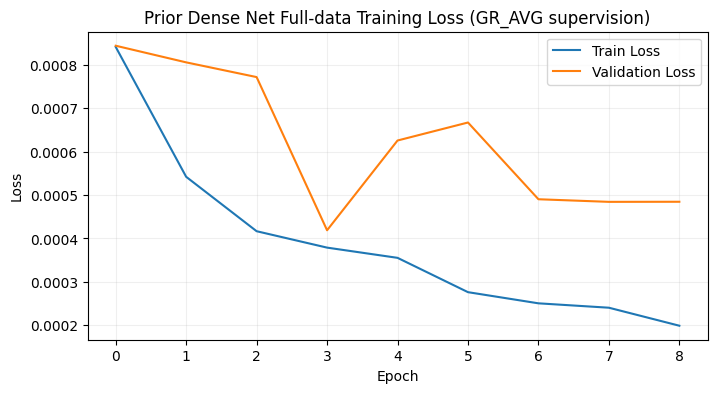

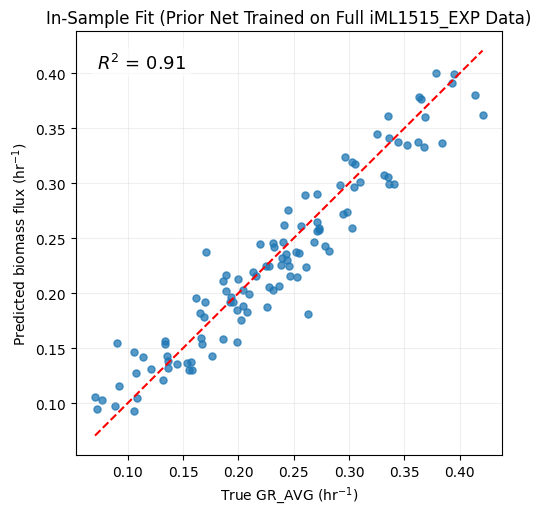

In [20]:
prior_net.eval()
with torch.no_grad():
    pred_var_all = prior_net(X_var)
    full_medium_all = compose_full_medium(pred_var_all)

    infer_batch = 1
    pred_parts = []
    for s_idx in range(0, full_medium_all.size(0), infer_batch):
        e_idx = min(s_idx + infer_batch, full_medium_all.size(0))
        c_all = medium_to_reservoir_input(full_medium_all[s_idx:e_idx])
        reservoir_all, _ = model(c_all, output_subset=None)
        pred_parts.append(reservoir_all[:, biomass_idx, -1].detach().cpu())
        if device.type == "cuda":
            torch.cuda.empty_cache()

    y_pred_all = torch.cat(pred_parts, dim=0).numpy()

y_true_all = y_growth.detach().cpu().numpy()
r2_growth = r2_score(y_true_all, y_pred_all)
mae_growth = mean_absolute_error(y_true_all, y_pred_all)
mse_growth = np.mean((y_true_all - y_pred_all) ** 2)

print("In-sample prior model fit on full experimental set")
print(f"R2:  {r2_growth:.4f}")
print(f"MAE: {mae_growth:.6f}")
print(f"MSE: {mse_growth:.6f}")
if "cv_r2_mean" in globals():
    print("\nCross-validated performance:")
    print(f"R2 : {cv_r2_mean:.4f} +/- {cv_r2_std:.4f}")
    print(f"MAE: {cv_mae_mean:.6f} +/- {cv_mae_std:.6f}")
    print(f"MSE: {cv_mse_mean:.6f} +/- {cv_mse_std:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(train_losses_prior, label="Train Loss")
if len(val_losses_prior) > 0:
    plt.plot(val_losses_prior, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Prior Dense Net Full-data Training Loss (GR_AVG supervision)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

plt.figure(figsize=(5.5, 5.5))
plt.scatter(y_true_all, y_pred_all, alpha=0.75, s=26)
min_v = float(min(y_true_all.min(), y_pred_all.min()))
max_v = float(max(y_true_all.max(), y_pred_all.max()))
plt.plot([min_v, max_v], [min_v, max_v], "r--", lw=1.5, label="Ideal")
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)")
plt.title("In-Sample Fit (Prior Net Trained on Full iML1515_EXP Data)")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_growth:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=13,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
#plt.legend()
plt.grid(alpha=0.2)


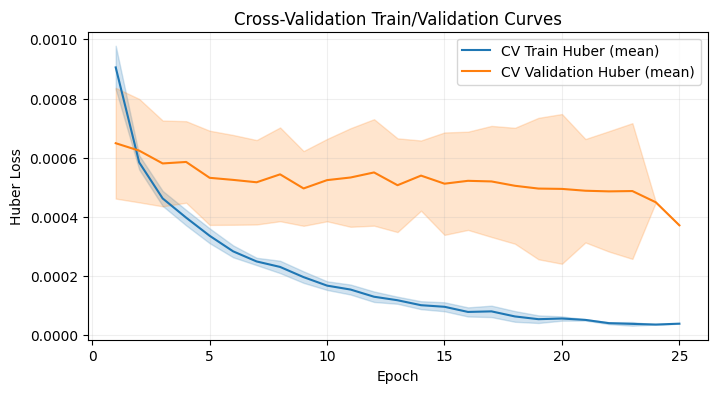


Per-fold CV metrics:
fold= 1 | R2=0.7682 | MAE=0.023955 | MSE=0.000743
fold= 2 | R2=0.8788 | MAE=0.026700 | MSE=0.000951
fold= 3 | R2=0.9181 | MAE=0.018640 | MSE=0.000442
fold= 4 | R2=0.7887 | MAE=0.027611 | MSE=0.001096
fold= 5 | R2=0.8337 | MAE=0.025105 | MSE=0.001035
fold= 6 | R2=0.8462 | MAE=0.024332 | MSE=0.000697
fold= 7 | R2=0.8742 | MAE=0.022421 | MSE=0.000772
fold= 8 | R2=0.8326 | MAE=0.037554 | MSE=0.002007
fold= 9 | R2=0.8854 | MAE=0.019256 | MSE=0.000615
fold=10 | R2=0.8755 | MAE=0.024514 | MSE=0.000898

Out-Of-Fold R2 (pooled): 0.8698


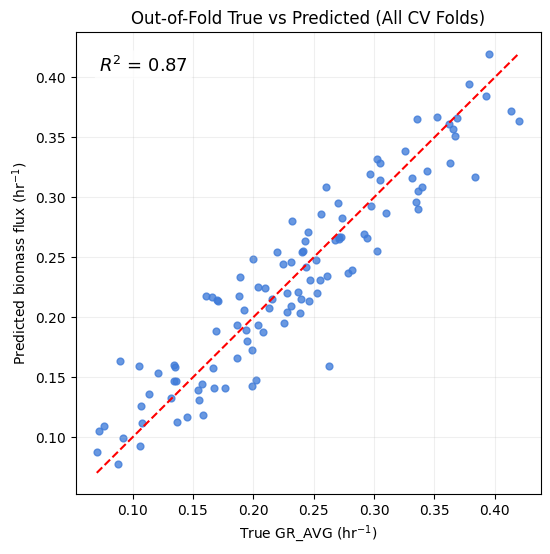

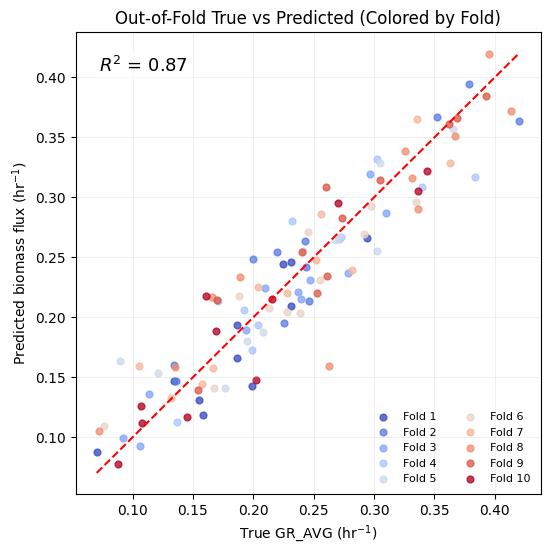

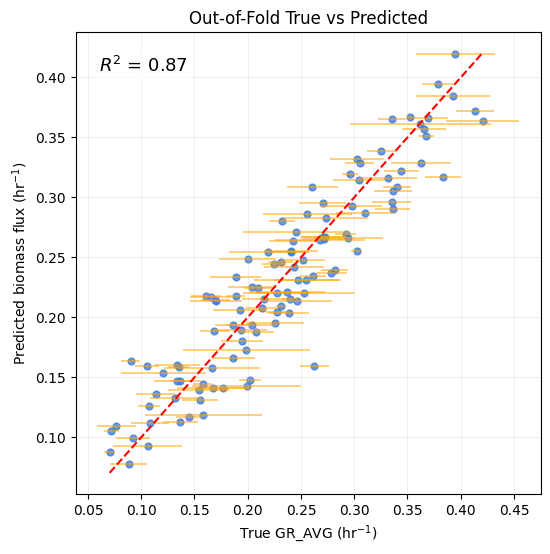

In [21]:
# CV diagnostics: mean train/validation curves, OOF scatter, and best-fold scatter
train_curves_cv = [np.array(f["train_losses"], dtype=np.float32) for f in fold_summaries]
val_curves_cv = [np.array(f["val_losses"], dtype=np.float32) for f in fold_summaries]

max_len_cv = max(len(c) for c in train_curves_cv)
train_mat_cv = np.full((len(train_curves_cv), max_len_cv), np.nan, dtype=np.float32)
val_mat_cv = np.full((len(val_curves_cv), max_len_cv), np.nan, dtype=np.float32)

for i, c in enumerate(train_curves_cv):
    train_mat_cv[i, :len(c)] = c
for i, c in enumerate(val_curves_cv):
    val_mat_cv[i, :len(c)] = c

epochs_cv = np.arange(1, max_len_cv + 1)
train_mean_cv = np.nanmean(train_mat_cv, axis=0)
train_std_cv = np.nanstd(train_mat_cv, axis=0)
val_mean_cv = np.nanmean(val_mat_cv, axis=0)
val_std_cv = np.nanstd(val_mat_cv, axis=0)

plt.figure(figsize=(8, 4))
plt.plot(epochs_cv, train_mean_cv, label="CV Train Huber (mean)", color="tab:blue")
plt.fill_between(epochs_cv, train_mean_cv - train_std_cv, train_mean_cv + train_std_cv, alpha=0.2, color="tab:blue")
plt.plot(epochs_cv, val_mean_cv, label="CV Validation Huber (mean)", color="tab:orange")
plt.fill_between(epochs_cv, val_mean_cv - val_std_cv, val_mean_cv + val_std_cv, alpha=0.2, color="tab:orange")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.title("Cross-Validation Train/Validation Curves")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

# Per-fold metrics
print("\nPer-fold CV metrics:")
for f in fold_summaries:
    print(
        f"fold={f['fold']:>2d} | "
        f"R2={f['r2']:.4f} | MAE={f['mae']:.6f} | MSE={f['mse']:.6f}"
    )

# Pooled OOF metric
r2_oof = r2_score(oof_true_cv, oof_pred_cv)
print(f"\nOut-Of-Fold R2 (pooled): {r2_oof:.4f}")


# OOF scatter (single color)
plt.figure(figsize=(6, 6))
plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
min_cv = float(min(oof_true_cv.min(), oof_pred_cv.min()))
max_cv = float(max(oof_true_cv.max(), oof_pred_cv.max()))
plt.plot([min_cv, max_cv], [min_cv, max_cv], "r--", lw=1.5)
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)")
plt.title("Out-of-Fold True vs Predicted (All CV Folds)")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_oof:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=13,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.grid(alpha=0.2)
plt.show()

# Additional OOF scatter colored by fold
plt.figure(figsize=(6, 6))
cmap = plt.get_cmap("coolwarm", n_splits)
for f in range(1, n_splits + 1):
    m = (oof_fold_cv == f)
    plt.scatter(oof_true_cv[m], oof_pred_cv[m], alpha=0.78, s=24, color=cmap(f - 1), label=f"Fold {f}")
plt.plot([min_cv, max_cv], [min_cv, max_cv], "r--", lw=1.5)
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)")
plt.title("Out-of-Fold True vs Predicted (Colored by Fold)")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_oof:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=13,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.grid(alpha=0.2)
plt.legend(ncol=2, fontsize=8, frameon=False)


# Third OOF plot: measured std as horizontal bars around true GR_AVG
plt.figure(figsize=(6, 6))
plt.hlines(
    y=oof_pred_cv,
    xmin=oof_true_cv - oof_std_cv,
    xmax=oof_true_cv + oof_std_cv,
    colors="orange",
    alpha=0.6,
    linewidth=1.2,
)
plt.scatter(oof_true_cv, oof_pred_cv, alpha=0.78, s=24, c="#3F7BD9")
plt.plot([min_cv, max_cv], [min_cv, max_cv], "r--", lw=1.5)
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)")
plt.title("Out-of-Fold True vs Predicted")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_oof:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=13,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.grid(alpha=0.2)
plt.show()


In [22]:
# Prior net input/output comparison (variable media only)
prior_net.eval()
with torch.no_grad():
    var_in = X_var.detach().cpu().numpy()                      # inputs to dense net
    var_out = prior_net(X_var).detach().cpu().numpy()          # outputs from dense net

in_cols = [f"in::{c}" for c in variable_input_cols]
out_cols = [f"out::{c}" for c in variable_input_cols]

compare_df = pd.DataFrame(
    np.concatenate([var_in, var_out], axis=1),
    columns=in_cols + out_cols
)

display(compare_df.head(10))


,in::EX_rib__D_e,in::EX_malt_e,in::EX_melib_e,in::EX_tre_e,in::EX_fru_e,in::EX_gal_e,in::EX_ac_e,in::EX_lac__D_e,in::EX_succ_e,in::EX_pyr_e,...,out::EX_malt_e,out::EX_melib_e,out::EX_tre_e,out::EX_fru_e,out::EX_gal_e,out::EX_ac_e,out::EX_lac__D_e,out::EX_succ_e,out::EX_pyr_e,out::EX_o2_e
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,1.800732,0.000000,0.000000,0.000000,0.000000,3.908259
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,1.265698,0.000000,0.000000,0.000000,0.000000,0.000000,3.255756
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.280225,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.634774
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.854858,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.070983
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.952041,2.398122
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.950758,0.000000,0.000000,0.000000,3.007969
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.384459,0.000000,0.000000,2.538654
7,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.630451
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,1.418645,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.157831
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.554494,0.000000,3.817574


### TabPFN on Experimental Data

In [37]:
from tabpfn import TabPFNRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error

EXP_PATH = "./experimental_data/iML1515_EXP.csv"
GROWTH_TARGET_COL = "GR_AVG"

exp_df_tabpfn = pd.read_csv(EXP_PATH).fillna(0.0)

# Normalize experimental column names to match expected reaction IDs.
# Example: EX_pi_e_i -> EX_pi_e
normalized_cols_tabpfn = {c: c[:-2] if c.endswith("_i") else c for c in exp_df_tabpfn.columns}
exp_df_tabpfn = exp_df_tabpfn.rename(columns=normalized_cols_tabpfn)

if GROWTH_TARGET_COL not in exp_df_tabpfn.columns:
    raise ValueError(f"Missing growth target column: {GROWTH_TARGET_COL}")

CARBON_SOURCE_COLS = [
    "EX_rib__D_e",
    "EX_malt_e",
    "EX_melib_e",
    "EX_tre_e",
    "EX_fru_e",
    "EX_gal_e",
    "EX_ac_e",
    "EX_lac__D_e",
    "EX_succ_e",
    "EX_pyr_e",
]
missing_carbon_cols = [c for c in CARBON_SOURCE_COLS if c not in exp_df_tabpfn.columns]
if missing_carbon_cols:
    raise ValueError(f"Missing required carbon source columns: {missing_carbon_cols}")

# Use only variable carbon sources as TabPFN features.
feature_cols = [c for c in CARBON_SOURCE_COLS if exp_df_tabpfn[c].nunique(dropna=False) > 1]
if len(feature_cols) == 0:
    raise ValueError("No variable carbon-source features found.")

# Safety check: these features are expected to be binary 0/1.
for c in feature_cols:
    vals = set(float(v) for v in pd.Series(exp_df_tabpfn[c]).dropna().unique().tolist())
    if not vals.issubset({0.0, 1.0}):
        raise ValueError(f"Feature {c} is not binary 0/1: {sorted(vals)}")

X_all = exp_df_tabpfn[feature_cols].to_numpy(dtype=np.float32)
y_all = exp_df_tabpfn[GROWTH_TARGET_COL].to_numpy(dtype=np.float32)

exp110_df = pd.read_csv("experimental_data/EXP110.csv")
if "GR_STD" not in exp110_df.columns:
    raise ValueError("EXP110.csv must contain GR_STD column.")
y_std_all = exp110_df["GR_STD"].to_numpy(dtype=np.float32)

stratify_y = exp_df_tabpfn[CARBON_SOURCE_COLS].gt(0).sum(axis=1).to_numpy(dtype=np.int64)
if np.any((stratify_y < 1) | (stratify_y > 4)):
    raise ValueError("Experimental strata must be carbon-source counts in {1,2,3,4}.")

n_samples = X_all.shape[0]
if y_std_all.shape[0] != n_samples:
    raise ValueError("EXP110.csv GR_STD length must match number of samples used in training.")

n_splits = 10
if n_samples < n_splits:
    raise ValueError("Need at least 10 samples for 10-fold stratified CV.")

strata_counts = np.bincount(stratify_y, minlength=5)[1:5]
if np.min(strata_counts) < n_splits:
    raise ValueError("Each carbon-source-count stratum must have at least 10 samples for 10-fold stratified CV.")

skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print("Stratification counts (1,2,3,4 carbons):", strata_counts.tolist())
print("Using variable carbon-source features:", feature_cols)
print(f"Samples: {n_samples}, features: {X_all.shape[1]}")

fold_summaries_tabpfn = []
oof_true_parts_tabpfn = []
oof_pred_parts_tabpfn = []
oof_std_parts_tabpfn = []

for fold_id, (tr_idx, va_idx) in enumerate(skf.split(np.arange(n_samples), stratify_y), start=1):
    X_train, X_val = X_all[tr_idx], X_all[va_idx]
    y_train, y_val = y_all[tr_idx], y_all[va_idx]

    reg = TabPFNRegressor(random_state=42)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_val).astype(np.float32)

    fold_r2 = r2_score(y_val, y_pred)
    fold_mae = mean_absolute_error(y_val, y_pred)
    fold_mse = float(np.mean((y_val - y_pred) ** 2))

    fold_summaries_tabpfn.append({
        "fold": int(fold_id),
        "r2": float(fold_r2),
        "mae": float(fold_mae),
        "mse": float(fold_mse),
    })

    oof_true_parts_tabpfn.append(y_val)
    oof_pred_parts_tabpfn.append(y_pred)
    oof_std_parts_tabpfn.append(y_std_all[va_idx])

    print(f"Fold {fold_id:>2d}/{n_splits} | R2={fold_r2:.4f} | MAE={fold_mae:.6f} | MSE={fold_mse:.6f}")

oof_true_tabpfn = np.concatenate(oof_true_parts_tabpfn)
oof_pred_tabpfn = np.concatenate(oof_pred_parts_tabpfn)
oof_std_tabpfn = np.concatenate(oof_std_parts_tabpfn)

cv_r2_mean_tabpfn = float(np.mean([f["r2"] for f in fold_summaries_tabpfn]))
cv_r2_std_tabpfn = float(np.std([f["r2"] for f in fold_summaries_tabpfn]))
cv_mae_mean_tabpfn = float(np.mean([f["mae"] for f in fold_summaries_tabpfn]))
cv_mae_std_tabpfn = float(np.std([f["mae"] for f in fold_summaries_tabpfn]))
cv_mse_mean_tabpfn = float(np.mean([f["mse"] for f in fold_summaries_tabpfn]))
cv_mse_std_tabpfn = float(np.std([f["mse"] for f in fold_summaries_tabpfn]))

r2_oof_tabpfn = r2_score(oof_true_tabpfn, oof_pred_tabpfn)
print(f"\nOOF R2 (pooled, TabPFN): {r2_oof_tabpfn:.4f}")
print(f"CV mean+/-std | R2: {cv_r2_mean_tabpfn:.4f} +/- {cv_r2_std_tabpfn:.4f}")
print(f"CV mean+/-std | MAE: {cv_mae_mean_tabpfn:.6f} +/- {cv_mae_std_tabpfn:.6f}")
print(f"CV mean+/-std | MSE: {cv_mse_mean_tabpfn:.6f} +/- {cv_mse_std_tabpfn:.6f}")



Stratification counts (1,2,3,4 carbons): [10, 20, 40, 40]
Using variable carbon-source features: ['EX_rib__D_e', 'EX_malt_e', 'EX_melib_e', 'EX_tre_e', 'EX_fru_e', 'EX_gal_e', 'EX_ac_e', 'EX_lac__D_e', 'EX_succ_e', 'EX_pyr_e']
Samples: 110, features: 10
Fold  1/10 | R2=0.5435 | MAE=0.032059 | MSE=0.001464
Fold  2/10 | R2=0.8261 | MAE=0.029074 | MSE=0.001365
Fold  3/10 | R2=0.8353 | MAE=0.024568 | MSE=0.000888
Fold  4/10 | R2=0.7566 | MAE=0.026709 | MSE=0.001263
Fold  5/10 | R2=0.8172 | MAE=0.029024 | MSE=0.001138
Fold  6/10 | R2=0.7550 | MAE=0.026152 | MSE=0.001110
Fold  7/10 | R2=0.8621 | MAE=0.022641 | MSE=0.000846
Fold  8/10 | R2=0.7178 | MAE=0.050407 | MSE=0.003383
Fold  9/10 | R2=0.7866 | MAE=0.029174 | MSE=0.001146
Fold 10/10 | R2=0.8480 | MAE=0.026828 | MSE=0.001096

OOF R2 (pooled, TabPFN): 0.8073
CV mean+/-std | R2: 0.7748 +/- 0.0887
CV mean+/-std | MAE: 0.029664 +/- 0.007358
CV mean+/-std | MSE: 0.001370 +/- 0.000695


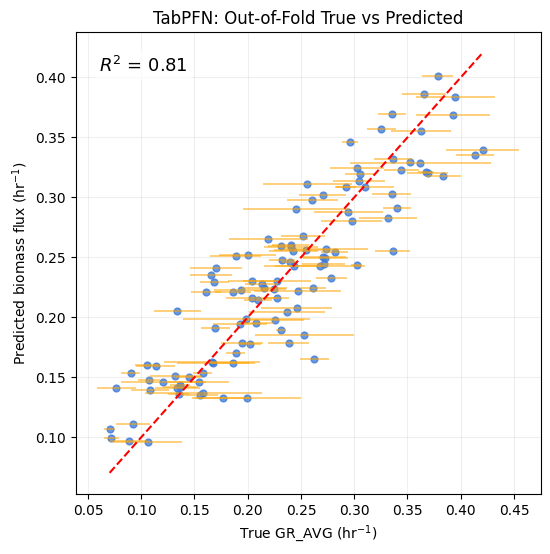

In [38]:
# TabPFN OOF plot with measured std as horizontal bars around true GR_AVG
r2_oof_tabpfn = r2_score(oof_true_tabpfn, oof_pred_tabpfn)

plt.figure(figsize=(6, 6))
min_cv = float(min(oof_true_tabpfn.min(), oof_pred_tabpfn.min()))
max_cv = float(max(oof_true_tabpfn.max(), oof_pred_tabpfn.max()))

plt.hlines(
    y=oof_pred_tabpfn,
    xmin=oof_true_tabpfn - oof_std_tabpfn,
    xmax=oof_true_tabpfn + oof_std_tabpfn,
    colors="orange",
    alpha=0.6,
    linewidth=1.2,
)
plt.scatter(oof_true_tabpfn, oof_pred_tabpfn, alpha=0.78, s=24, c="#3F7BD9")
plt.plot([min_cv, max_cv], [min_cv, max_cv], "r--", lw=1.5)
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)")
plt.title("TabPFN: Out-of-Fold True vs Predicted")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_oof_tabpfn:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=13,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.grid(alpha=0.2)
plt.show()


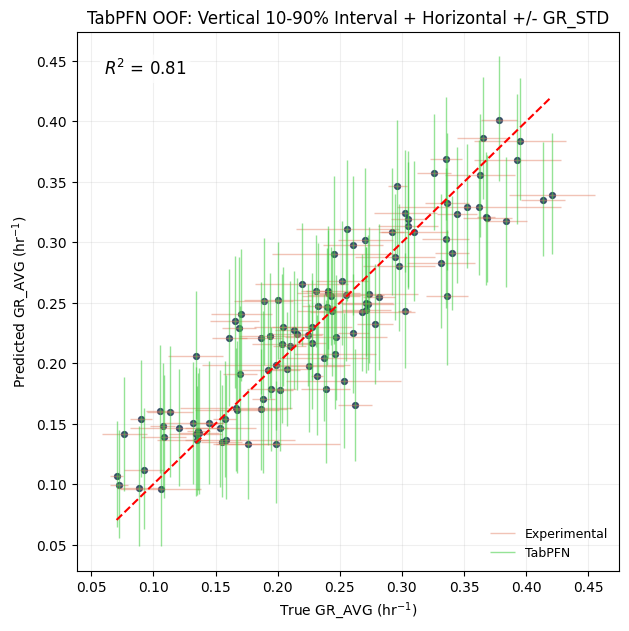

In [ ]:
# TabPFN uncertainty diagnostics (OOF): prediction intervals per OOF point only
# Requires cell 30 to be run first (defines feature_cols, stratify_y, n_splits, X_all, y_all, y_std_all).

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score
from tabpfn import TabPFNRegressor

q_list = [0.10, 0.50, 0.90]

def _to_quantile_dict(pred_q, quantiles):
    if isinstance(pred_q, dict):
        if "quantiles" in pred_q:
            q_vals = pred_q["quantiles"]
            return {float(q): np.asarray(arr).reshape(-1) for q, arr in zip(quantiles, q_vals)}
        if "predictions" in pred_q:
            q_vals = pred_q["predictions"]
            return {float(q): np.asarray(arr).reshape(-1) for q, arr in zip(quantiles, q_vals)}
        out = {}
        for k, v in pred_q.items():
            try:
                qk = float(k)
                out[qk] = np.asarray(v).reshape(-1)
            except Exception:
                pass
        if len(out) > 0:
            return out
        raise ValueError("Unsupported quantile dict format returned by TabPFNRegressor.predict().")

    if isinstance(pred_q, (list, tuple)):
        return {float(q): np.asarray(arr).reshape(-1) for q, arr in zip(quantiles, pred_q)}

    arr = np.asarray(pred_q)
    if arr.ndim == 2 and arr.shape[1] == len(quantiles):
        return {float(q): arr[:, i].reshape(-1) for i, q in enumerate(quantiles)}

    raise ValueError("Unsupported quantile output format from TabPFNRegressor.predict().")


# Build OOF quantiles fold-by-fold
skf_uq = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_true_uq_parts = []
oof_std_uq_parts = []
oof_q_parts = {q: [] for q in q_list}

for fold_id, (tr_idx, va_idx) in enumerate(skf_uq.split(np.arange(X_all.shape[0]), stratify_y), start=1):
    X_train, X_val = X_all[tr_idx], X_all[va_idx]
    y_train, y_val = y_all[tr_idx], y_all[va_idx]

    reg_uq = TabPFNRegressor(random_state=42)
    reg_uq.fit(X_train, y_train)

    try:
        q_pred_raw = reg_uq.predict(X_val, output_type="quantiles", quantiles=q_list)
    except TypeError:
        q_pred_raw = reg_uq.predict(X_val, quantiles=q_list)

    q_pred = _to_quantile_dict(q_pred_raw, q_list)

    oof_true_uq_parts.append(y_val)
    oof_std_uq_parts.append(y_std_all[va_idx])
    for q in q_list:
        if q not in q_pred:
            raise ValueError(f"Quantile {q} missing in TabPFN output for fold {fold_id}.")
        oof_q_parts[q].append(np.asarray(q_pred[q], dtype=np.float32).reshape(-1))

oof_true_uq = np.concatenate(oof_true_uq_parts)
oof_std_uq = np.concatenate(oof_std_uq_parts)
oof_q = {q: np.concatenate(parts) for q, parts in oof_q_parts.items()}

pred_q10 = oof_q[0.10]
pred_q90 = oof_q[0.90]
r2_uq = r2_score(oof_true_tabpfn, oof_pred_tabpfn)

# Prediction intervals per OOF point: vertical model interval + horizontal +/- GR_STD
plt.figure(figsize=(7, 7))

# Horizontal bars = experimental uncertainty (+/- GR_STD)
plt.hlines(
    y=oof_pred_tabpfn,
    xmin=oof_true_uq - oof_std_uq,
    xmax=oof_true_uq + oof_std_uq,
    colors="#E07A5F",
    alpha=0.45,
    linewidth=1.0,
    label="Experimental",
)

# Vertical bars = model predictive interval (q10-q90)
plt.vlines(
    x=oof_true_uq,
    ymin=pred_q10,
    ymax=pred_q90,
    colors="#3ECC40",
    alpha=0.55,
    linewidth=1.0,
    label="TabPFN",
)

# Point predictions from cell 30
plt.scatter(
    oof_true_uq,
    oof_pred_tabpfn,
    s=18,
    alpha=0.8,
    color="#1D3557",
    label="_nolegend_",
)

min_v = float(min(oof_true_uq.min(), oof_pred_tabpfn.min()))
max_v = float(max(oof_true_uq.max(), oof_pred_tabpfn.max()))
plt.plot([min_v, max_v], [min_v, max_v], "r--", lw=1.5, label="_nolegend_")
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted GR_AVG (hr$^{-1}$)")
plt.title("TabPFN OOF: Vertical 10-90% Interval + Horizontal +/- GR_STD")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_uq:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=12,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.legend(frameon=False, fontsize=9, loc="lower right")
plt.grid(alpha=0.2)
plt.show()

### Experiment: Replace PriorNet Mapper with TabPFN Mapper for FluxTransformer

Goal: keep FluxTransformer as the mechanistic readout, but replace the learnable PriorNet mapper with a TabPFN-based mapper from experimental media flags to variable bounds.
The mapper is trained **against GR_AVG as the supervision goal** via a latent-bound fitting stage on each CV fold, then TabPFN learns to imitate those fitted bounds.


In [72]:
import numpy as np
import torch
import torch.nn as nn
from copy import deepcopy
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error
from tabpfn import TabPFNRegressor

# ------------------------------------------------------------------
# TabPFN mapper in place of PriorDenseNet:
# 11 binary inputs (10 carbons + oxygen) -> 11 bounds -> frozen FluxTransformer -> GR_AVG
# ------------------------------------------------------------------

required = [
    "model", "inputs", "outputs", "input_token_indices",
    "X_var", "y_growth", "variable_input_cols", "fixed_input_cols",
    "biomass_idx", "stratify_y"
]
missing = [k for k in required if k not in globals()]
if missing:
    raise ValueError(f"Missing required variables/functions: {missing}. Run reservoir setup cells first.")

# Use CPU for this experiment to avoid CUDA OOM from repeated backprop through FluxTransformer.
run_device = torch.device("cpu")
print(f"Running TabPFN-mapper experiment on device: {run_device}")

# Build local indices/tensors on run_device.
var_pos_local = torch.tensor([inputs.index(c) for c in variable_input_cols], dtype=torch.long, device=run_device)
fixed_pos_local = torch.tensor([inputs.index(c) for c in fixed_input_cols], dtype=torch.long, device=run_device)
token_idx_local = torch.tensor(input_token_indices, dtype=torch.long, device=run_device)

if "fixed_values" in globals() and isinstance(fixed_values, torch.Tensor):
    fixed_values_local = torch.tensor(fixed_values.detach().cpu().numpy(), dtype=torch.float32, device=run_device)
else:
    fixed_values_local = torch.empty(0, dtype=torch.float32, device=run_device)


def compose_full_medium_local(var_part):
    batch = var_part.size(0)
    full_medium = torch.zeros(batch, len(inputs), dtype=torch.float32, device=var_part.device)
    full_medium[:, var_pos_local] = var_part
    if fixed_values_local.numel() > 0:
        full_medium[:, fixed_pos_local] = fixed_values_local.unsqueeze(0).expand(batch, -1)
    return torch.clamp(full_medium, min=0.0)


def medium_to_reservoir_input_local(full_medium):
    c = torch.zeros(full_medium.size(0), len(outputs), 1, dtype=torch.float32, device=full_medium.device)
    c[:, token_idx_local, 0] = full_medium
    return c


# Frozen model copy on CPU (keeps original model untouched).
model_run = deepcopy(model).to(run_device)
for p in model_run.parameters():
    p.requires_grad = False
model_run.eval()

X_map_np = X_var.detach().cpu().numpy().astype(np.float32)
y_map_np = y_growth.detach().cpu().numpy().astype(np.float32)
stratify_arr = np.asarray(stratify_y, dtype=np.int64)

n_samples = X_map_np.shape[0]
n_var = X_map_np.shape[1]
n_splits_map = 10
if n_samples < n_splits_map:
    raise ValueError("Need at least 10 samples for 10-fold stratified CV.")

strata_counts_map = np.bincount(stratify_arr, minlength=5)[1:5]
if np.min(strata_counts_map) < n_splits_map:
    raise ValueError("Each stratum must have at least 10 samples for 10-fold CV.")

# Bounds scale exactly as in prior setup.
out_scale_vec = np.array([10.0 if c == "EX_o2_e" else 2.2 for c in variable_input_cols], dtype=np.float32)
out_scale_t = torch.tensor(out_scale_vec, dtype=torch.float32, device=run_device).view(1, -1)

# Stage-A latent fitting hyperparameters (GR_AVG-supervised stage).
# These are intentionally stronger than before to avoid underfitting latent targets.
latent_max_steps = 160
latent_patience = 20
latent_lr = 0.03
latent_reg = 1e-4
latent_batch = 2
eval_batch = 1
criterion_latent = nn.MSELoss()

skf_map = StratifiedKFold(n_splits=n_splits_map, shuffle=True, random_state=42)

fold_summaries_tabpfn_mapper = []
oof_true_parts_mapper = []
oof_pred_parts_mapper = []

print("Stratification counts (1,2,3,4 carbons):", strata_counts_map.tolist())
print(f"Mapper input dims: {n_var} (expected 11 = 10 carbons + oxygen)")
print(
    f"Latent fitting config: max_steps={latent_max_steps}, patience={latent_patience}, "
    f"lr={latent_lr}, reg={latent_reg}, batch={latent_batch}"
)

for fold_id, (tr_idx, va_idx) in enumerate(skf_map.split(np.arange(n_samples), stratify_arr), start=1):
    X_tr_np, X_va_np = X_map_np[tr_idx], X_map_np[va_idx]
    y_tr_np, y_va_np = y_map_np[tr_idx], y_map_np[va_idx]

    X_tr_t = torch.tensor(X_tr_np, dtype=torch.float32, device=run_device)
    y_tr_t = torch.tensor(y_tr_np, dtype=torch.float32, device=run_device)

    mask_tr = (X_tr_t > 0).float()

    # Initialize latent bounds near moderate uptake for present nutrients.
    init_rates = mask_tr * (0.6 * out_scale_t)
    init_anchor = init_rates.detach()

    eps = 1e-4
    init_ratio = torch.clamp(init_rates / (out_scale_t + eps), eps, 1 - eps)
    z_tr = torch.log(init_ratio / (1 - init_ratio)).detach().clone().requires_grad_(True)
    opt_latent = torch.optim.Adam([z_tr], lr=latent_lr)

    best_loss = float("inf")
    best_z = z_tr.detach().clone()
    no_improve = 0

    # Stage A: infer per-sample latent 11-dim bounds that match GR_AVG through frozen FT.
    for step in range(latent_max_steps):
        perm = torch.randperm(X_tr_t.size(0), device=run_device)
        running = 0.0

        for s in range(0, X_tr_t.size(0), latent_batch):
            bi = perm[s:s + latent_batch]
            y_b = y_tr_t[bi]
            m_b = mask_tr[bi]

            opt_latent.zero_grad(set_to_none=True)

            rates_b = torch.sigmoid(z_tr[bi]) * out_scale_t * m_b
            full_b = compose_full_medium_local(rates_b)
            c_b = medium_to_reservoir_input_local(full_b)
            pred_b, _ = model_run(c_b, output_subset=None)
            gr_b = pred_b[:, biomass_idx, -1]

            loss_fit = criterion_latent(gr_b, y_b)
            loss_reg = torch.mean((rates_b - init_anchor[bi]) ** 2)
            loss = loss_fit + latent_reg * loss_reg

            loss.backward()
            torch.nn.utils.clip_grad_norm_([z_tr], max_norm=1.0)
            opt_latent.step()
            running += loss.item() * bi.numel()

        epoch_loss = running / max(1, X_tr_t.size(0))

        if epoch_loss < best_loss - 1e-8:
            best_loss = epoch_loss
            best_z = z_tr.detach().clone()
            no_improve = 0
        else:
            no_improve += 1

        if (step + 1) % 20 == 0 or step == 0:
            print(
                f"Fold {fold_id}/{n_splits_map} latent-step {step+1:>3}/{latent_max_steps} "
                f"| train_mse={epoch_loss:.6f} | no_improve={no_improve}"
            )

        if no_improve >= latent_patience:
            print(
                f"Fold {fold_id}/{n_splits_map} latent early-stop at step {step+1} "
                f"(best_mse={best_loss:.6f})"
            )
            break

    # Use best latent solution from Stage A.
    z_fit = best_z
    with torch.no_grad():
        latent_bounds_tr = (torch.sigmoid(z_fit) * out_scale_t * mask_tr).detach().cpu().numpy().astype(np.float32)

    # Stage-A train-fit diagnostics (important sanity check).
    with torch.no_grad():
        train_pred_parts = []
        for s_idx in range(0, X_tr_t.size(0), eval_batch):
            e_idx = min(s_idx + eval_batch, X_tr_t.size(0))
            m_chunk = mask_tr[s_idx:e_idx]
            b_chunk = torch.sigmoid(z_fit[s_idx:e_idx]) * out_scale_t * m_chunk
            full_chunk = compose_full_medium_local(b_chunk)
            c_chunk = medium_to_reservoir_input_local(full_chunk)
            pred_chunk, _ = model_run(c_chunk, output_subset=None)
            train_pred_parts.append(pred_chunk[:, biomass_idx, -1].detach().cpu())

        yhat_tr = torch.cat(train_pred_parts, dim=0).numpy().astype(np.float32)

    stageA_r2 = r2_score(y_tr_np, yhat_tr)
    stageA_mae = mean_absolute_error(y_tr_np, yhat_tr)
    stageA_mse = float(np.mean((y_tr_np - yhat_tr) ** 2))
    print(
        f"Fold {fold_id:>2d}/{n_splits_map} Stage-A fit | "
        f"R2={stageA_r2:.4f} | MAE={stageA_mae:.6f} | MSE={stageA_mse:.6f}"
    )

    # Stage B: train TabPFN mapper X -> latent bounds (11 separate regressors).
    bounds_va_pred = np.zeros((X_va_np.shape[0], n_var), dtype=np.float32)
    for j in range(n_var):
        yb = latent_bounds_tr[:, j]
        if np.std(yb) < 1e-8:
            bounds_va_pred[:, j] = float(yb[0])
            continue

        reg_j = TabPFNRegressor(random_state=42)
        reg_j.fit(X_tr_np, yb)
        bounds_va_pred[:, j] = reg_j.predict(X_va_np).astype(np.float32)

    # Physical bounds + absent nutrient masking.
    bounds_va_pred = np.clip(bounds_va_pred, 0.0, out_scale_vec.reshape(1, -1))
    bounds_va_pred *= (X_va_np > 0).astype(np.float32)

    # Evaluate via frozen FluxTransformer (same readout idea as reservoir experiment).
    with torch.no_grad():
        b_va_t = torch.tensor(bounds_va_pred, dtype=torch.float32, device=run_device)
        yhat_parts = []
        for s_idx in range(0, b_va_t.size(0), eval_batch):
            e_idx = min(s_idx + eval_batch, b_va_t.size(0))
            b_chunk = b_va_t[s_idx:e_idx]
            full_chunk = compose_full_medium_local(b_chunk)
            c_chunk = medium_to_reservoir_input_local(full_chunk)
            pred_chunk, _ = model_run(c_chunk, output_subset=None)
            yhat_parts.append(pred_chunk[:, biomass_idx, -1].detach().cpu())

        yhat_va = torch.cat(yhat_parts, dim=0).numpy().astype(np.float32)

    fold_r2 = r2_score(y_va_np, yhat_va)
    fold_mae = mean_absolute_error(y_va_np, yhat_va)
    fold_mse = float(np.mean((y_va_np - yhat_va) ** 2))

    fold_summaries_tabpfn_mapper.append({
        "fold": int(fold_id),
        "r2": float(fold_r2),
        "mae": float(fold_mae),
        "mse": float(fold_mse),
        "stageA_r2": float(stageA_r2),
        "stageA_mae": float(stageA_mae),
        "stageA_mse": float(stageA_mse),
    })
    oof_true_parts_mapper.append(y_va_np)
    oof_pred_parts_mapper.append(yhat_va)

    print(f"Fold {fold_id:>2d}/{n_splits_map} | R2={fold_r2:.4f} | MAE={fold_mae:.6f} | MSE={fold_mse:.6f}")

oof_true_tabpfn_mapper = np.concatenate(oof_true_parts_mapper)
oof_pred_tabpfn_mapper = np.concatenate(oof_pred_parts_mapper)

r2_oof_mapper = r2_score(oof_true_tabpfn_mapper, oof_pred_tabpfn_mapper)
cv_r2_mapper = np.array([f["r2"] for f in fold_summaries_tabpfn_mapper], dtype=np.float32)
cv_mae_mapper = np.array([f["mae"] for f in fold_summaries_tabpfn_mapper], dtype=np.float32)
cv_mse_mapper = np.array([f["mse"] for f in fold_summaries_tabpfn_mapper], dtype=np.float32)
cv_stageA_r2 = np.array([f["stageA_r2"] for f in fold_summaries_tabpfn_mapper], dtype=np.float32)

print("\nTabPFN-mapper + Frozen FluxTransformer results")
print(f"OOF R2 (pooled): {r2_oof_mapper:.4f}")
print(f"CV mean+/-std | R2:  {cv_r2_mapper.mean():.4f} +/- {cv_r2_mapper.std():.4f}")
print(f"CV mean+/-std | MAE: {cv_mae_mapper.mean():.6f} +/- {cv_mae_mapper.std():.6f}")
print(f"CV mean+/-std | MSE: {cv_mse_mapper.mean():.6f} +/- {cv_mse_mapper.std():.6f}")
print(f"Stage-A mean R2 across folds: {cv_stageA_r2.mean():.4f}")

if "r2_oof" in globals():
    print(f"Compared to PriorNet+FT OOF R2 : {float(r2_oof):.4f} | delta={r2_oof_mapper - float(r2_oof):+.4f}")
if "r2_oof_tabpfn" in globals():
    print(f"Compared to Direct TabPFN OOF R2: {float(r2_oof_tabpfn):.4f} | delta={r2_oof_mapper - float(r2_oof_tabpfn):+.4f}")



Running TabPFN-mapper experiment on device: cpu
Stratification counts (1,2,3,4 carbons): [10, 20, 40, 40]
Mapper input dims: 11 (expected 11 = 10 carbons + oxygen)
Latent fitting config: max_steps=160, patience=20, lr=0.03, reg=0.0001, batch=2
Fold 1/10 latent-step   1/160 | train_mse=0.009278 | no_improve=0
Fold 1/10 latent-step  20/160 | train_mse=0.000072 | no_improve=0
Fold 1/10 latent-step  40/160 | train_mse=0.000180 | no_improve=8
Fold 1/10 latent early-stop at step 52 (best_mse=0.000064)
Fold  1/10 Stage-A fit | R2=0.9972 | MAE=0.001836 | MSE=0.000021
Fold  1/10 | R2=0.6039 | MAE=0.029219 | MSE=0.001270
Fold 2/10 latent-step   1/160 | train_mse=0.010009 | no_improve=0
Fold 2/10 latent-step  20/160 | train_mse=0.000091 | no_improve=3
Fold 2/10 latent-step  40/160 | train_mse=0.000145 | no_improve=12
Fold 2/10 latent early-stop at step 48 (best_mse=0.000074)
Fold  2/10 Stage-A fit | R2=0.9965 | MAE=0.002216 | MSE=0.000025
Fold  2/10 | R2=0.7682 | MAE=0.033106 | MSE=0.001819
Fold 

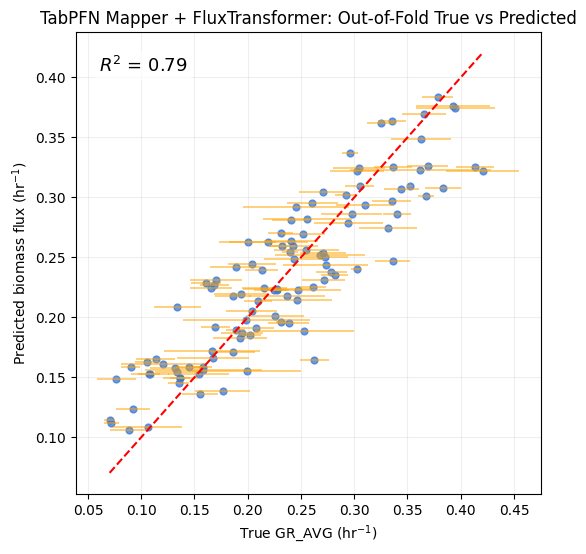

In [73]:
# OOF plot for TabPFN-mapper + Frozen FluxTransformer (with experimental +/- GR_STD)
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score

required = ["oof_true_tabpfn_mapper", "oof_pred_tabpfn_mapper", "stratify_y"]
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f"Missing required variables for plotting: {missing}. Run the mapper experiment cell first.")

exp110_df_plot = pd.read_csv("experimental_data/EXP110.csv")
if "GR_STD" not in exp110_df_plot.columns:
    raise ValueError("EXP110.csv must contain GR_STD column.")
y_std_all_plot = exp110_df_plot["GR_STD"].to_numpy(dtype=np.float32)

n_samples_plot = len(oof_true_tabpfn_mapper)
if y_std_all_plot.shape[0] != n_samples_plot:
    raise ValueError("EXP110.csv GR_STD length must match mapper OOF sample count.")

# Rebuild OOF std ordering to match concatenated fold-by-fold order from mapper experiment.
strat_arr_plot = np.asarray(stratify_y, dtype=np.int64)
skf_plot = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_std_parts_plot = []
for _, va_idx in skf_plot.split(np.arange(n_samples_plot), strat_arr_plot):
    oof_std_parts_plot.append(y_std_all_plot[va_idx])
oof_std_tabpfn_mapper = np.concatenate(oof_std_parts_plot, axis=0)

r2_mapper_plot = r2_score(oof_true_tabpfn_mapper, oof_pred_tabpfn_mapper)

plt.figure(figsize=(6, 6))
plt.hlines(
    y=oof_pred_tabpfn_mapper,
    xmin=oof_true_tabpfn_mapper - oof_std_tabpfn_mapper,
    xmax=oof_true_tabpfn_mapper + oof_std_tabpfn_mapper,
    colors="orange",
    alpha=0.6,
    linewidth=1.2,
)
plt.scatter(oof_true_tabpfn_mapper, oof_pred_tabpfn_mapper, alpha=0.78, s=24, c="#3F7BD9")
min_v = float(min(oof_true_tabpfn_mapper.min(), oof_pred_tabpfn_mapper.min()))
max_v = float(max(oof_true_tabpfn_mapper.max(), oof_pred_tabpfn_mapper.max()))
plt.plot([min_v, max_v], [min_v, max_v], "r--", lw=1.5)
plt.xlabel(r"True GR_AVG (hr$^{-1}$)")
plt.ylabel(r"Predicted biomass flux (hr$^{-1}$)")
plt.title("TabPFN Mapper + FluxTransformer: Out-of-Fold True vs Predicted")
plt.text(0.05, 0.95, rf"$R^2$ = {r2_mapper_plot:.2f}", transform=plt.gca().transAxes,
         ha="left", va="top", fontsize=13,
         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.75))
plt.grid(alpha=0.2)
plt.show()

